Importación de librerias

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt  

Se carga el dataset

In [ ]:
df = pd.read_csv("data/hotel_bookings.csv")

Dimensiones del dataset

In [ ]:
filas, columnas = df.shape
print(f"Cantidad de filas: {filas}")
print(f"Cantidad de columnas: {columnas}")

Cantidad de filas: 119390
Cantidad de columnas: 32


In [ ]:
# Ver todas las columnas
print("Columnas del dataset:\n")
print(df.columns)

Columnas del dataset:

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


Tipo y cantidad de registros por columna

In [ ]:
# Subset primeras 16 columnas
primeras_16 = df.iloc[:, :16]

print("===== PRIMERAS 16 COLUMNAS =====\n")
print(primeras_16.info())

===== PRIMERAS 16 COLUMNAS =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   hotel                      119390 non-null  object 
 1   is_canceled                119390 non-null  int64  
 2   lead_time                  119390 non-null  int64  
 3   arrival_date_year          119390 non-null  int64  
 4   arrival_date_month         119390 non-null  object 
 5   arrival_date_week_number   119390 non-null  int64  
 6   arrival_date_day_of_month  119390 non-null  int64  
 7   stays_in_weekend_nights    119390 non-null  int64  
 8   stays_in_week_nights       119390 non-null  int64  
 9   adults                     119390 non-null  int64  
 10  children                   119386 non-null  float64
 11  babies                     119390 non-null  int64  
 12  meal                       119390 non-null  object 


In [ ]:
# Subset últimas 16 columnas
ultimas_16 = df.iloc[:, 16:]

print("===== ÚLTIMAS 16 COLUMNAS =====\n")
print(ultimas_16.info())

===== ÚLTIMAS 16 COLUMNAS =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_repeated_guest               119390 non-null  int64  
 1   previous_cancellations          119390 non-null  int64  
 2   previous_bookings_not_canceled  119390 non-null  int64  
 3   reserved_room_type              119390 non-null  object 
 4   assigned_room_type              119390 non-null  object 
 5   booking_changes                 119390 non-null  int64  
 6   deposit_type                    119390 non-null  object 
 7   agent                           103050 non-null  float64
 8   company                         6797 non-null    float64
 9   days_in_waiting_list            119390 non-null  int64  
 10  customer_type                   119390 non-null  object 
 11  adr                             119390 non-nu

Nulos

In [ ]:
#analisis de nulos primeras 16 columnas 
primeras_16 = df.iloc[:, :16]

print("Valores nulos por columna (primeras 16):\n")
print(primeras_16.isnull().sum())
total_nulos_primeras = primeras_16.isnull().sum().sum()
print("\nTotal de valores nulos en las primeras 16 columnas:", total_nulos_primeras)

Valores nulos por columna (primeras 16):

hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_year              0
arrival_date_month             0
arrival_date_week_number       0
arrival_date_day_of_month      0
stays_in_weekend_nights        0
stays_in_week_nights           0
adults                         0
children                       4
babies                         0
meal                           0
country                      488
market_segment                 0
distribution_channel           0
dtype: int64

Total de valores nulos en las primeras 16 columnas: 492


In [21]:
#analisis de nulos ultimas 16 columnas 

ultimas_16 = df.iloc[:, -16:]

print("\nValores nulos por columna (últimas 16):\n")
print(ultimas_16.isnull().sum())
total_nulos_ultimas = ultimas_16.isnull().sum().sum()
print("\nTotal de valores nulos en las últimas 16 columnas:", total_nulos_ultimas)



Valores nulos por columna (últimas 16):

is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company                           112593
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
reservation_status_date                0
dtype: int64

Total de valores nulos en las últimas 16 columnas: 128933


Sustituimos los valores nulos en la variable "CHILDREN" y lo remplazamos por la mediana.

In [ ]:
#se averigua la mediana para reemplazar los valores nulos en esa columna 
mediana_children = df['children'].median()
print("La mediana de children es:", mediana_children)

La mediana de children es: 0.0


In [ ]:
# children: reemplazar nulos por 0 (si no hay niños)
df['children'] = df['children'].fillna(0)

Reemplazamos los nulos de la columna "COUNTRY" por desconocido 'Unknown'

In [ ]:
df['country'] = df['country'].fillna('Unknown')

Reemplazamos los nulos de "AGENT" por 0 ya que es numerica la columna 

In [ ]:
df['agent'] = df['agent'].fillna(0)

In [ ]:
#se reemplazan los nan de la columna company por 0, ya que es de tipo float (con comapañia vs sin compañia)
df['company'] = df['company'].fillna(0)


In [27]:
#analisis de nulos primeras 16 columnas 
primeras_16 = df.iloc[:, :16]

print("Valores nulos por columna (primeras 16):\n")
print(primeras_16.isnull().sum())
total_nulos_primeras = primeras_16.isnull().sum().sum()
print("\nTotal de valores nulos en las primeras 16 columnas:", total_nulos_primeras)

Valores nulos por columna (primeras 16):

hotel                        0
is_canceled                  0
lead_time                    0
arrival_date_year            0
arrival_date_month           0
arrival_date_week_number     0
arrival_date_day_of_month    0
stays_in_weekend_nights      0
stays_in_week_nights         0
adults                       0
children                     0
babies                       0
meal                         0
country                      0
market_segment               0
distribution_channel         0
dtype: int64

Total de valores nulos en las primeras 16 columnas: 0


In [28]:
#analisis de nulos ultimas 16 columnas 

ultimas_16 = df.iloc[:, -16:]

print("\nValores nulos por columna (últimas 16):\n")
print(ultimas_16.isnull().sum())
total_nulos_ultimas = ultimas_16.isnull().sum().sum()
print("\nTotal de valores nulos en las últimas 16 columnas:", total_nulos_ultimas)


Valores nulos por columna (últimas 16):

is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
reservation_status                0
reservation_status_date           0
dtype: int64

Total de valores nulos en las últimas 16 columnas: 0


Filas duplicadas

In [29]:
# Filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 31994


In [30]:
df_final = df.copy()
print("--- 1. Conteo Total de Valores Nulos (NaNs) ---")
# Esto cuenta los NaNs por columna y muestra las que aún tienen nulos
null_counts = df_final.isnull().sum()
if (null_counts > 0).any():
    print("❌ Columnas con valores nulos restantes:")
    print(null_counts[null_counts > 0])
else:
    print("✅ ¡El DataFrame está libre de valores nulos!")

--- 1. Conteo Total de Valores Nulos (NaNs) ---
✅ ¡El DataFrame está libre de valores nulos!


In [31]:
# Eliminamos filas duplicadas
df = df.drop_duplicates()

# Verificamos que se eliminaron
duplicados = df.duplicated().sum()
print(f"Filas duplicadas después de eliminar: {duplicados}")

Filas duplicadas después de eliminar: 0


In [32]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138633,0.010824,0.039075,0.030413,0.183990,0.271603,81.004657,11.016809,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455871,0.113597,0.193775,0.369145,1.731894,0.727245,109.945638,54.047484,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
# Se utiliza la funcion round para visualizar mejor los datos
df.describe().round()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0,87396.0
mean,0.0,80.0,2016.0,27.0,16.0,1.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,81.0,11.0,1.0,106.0,0.0,1.0
std,0.0,86.0,1.0,14.0,9.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,110.0,54.0,10.0,55.0,0.0,1.0
min,0.0,0.0,2015.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.0,0.0,0.0
25%,0.0,11.0,2016.0,16.0,8.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,72.0,0.0,0.0
50%,0.0,49.0,2016.0,27.0,16.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,98.0,0.0,0.0
75%,1.0,125.0,2017.0,37.0,23.0,2.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,234.0,0.0,0.0,134.0,0.0,1.0
max,1.0,737.0,2017.0,53.0,31.0,19.0,50.0,55.0,10.0,10.0,1.0,26.0,72.0,21.0,535.0,543.0,391.0,5400.0,8.0,5.0


Outliers

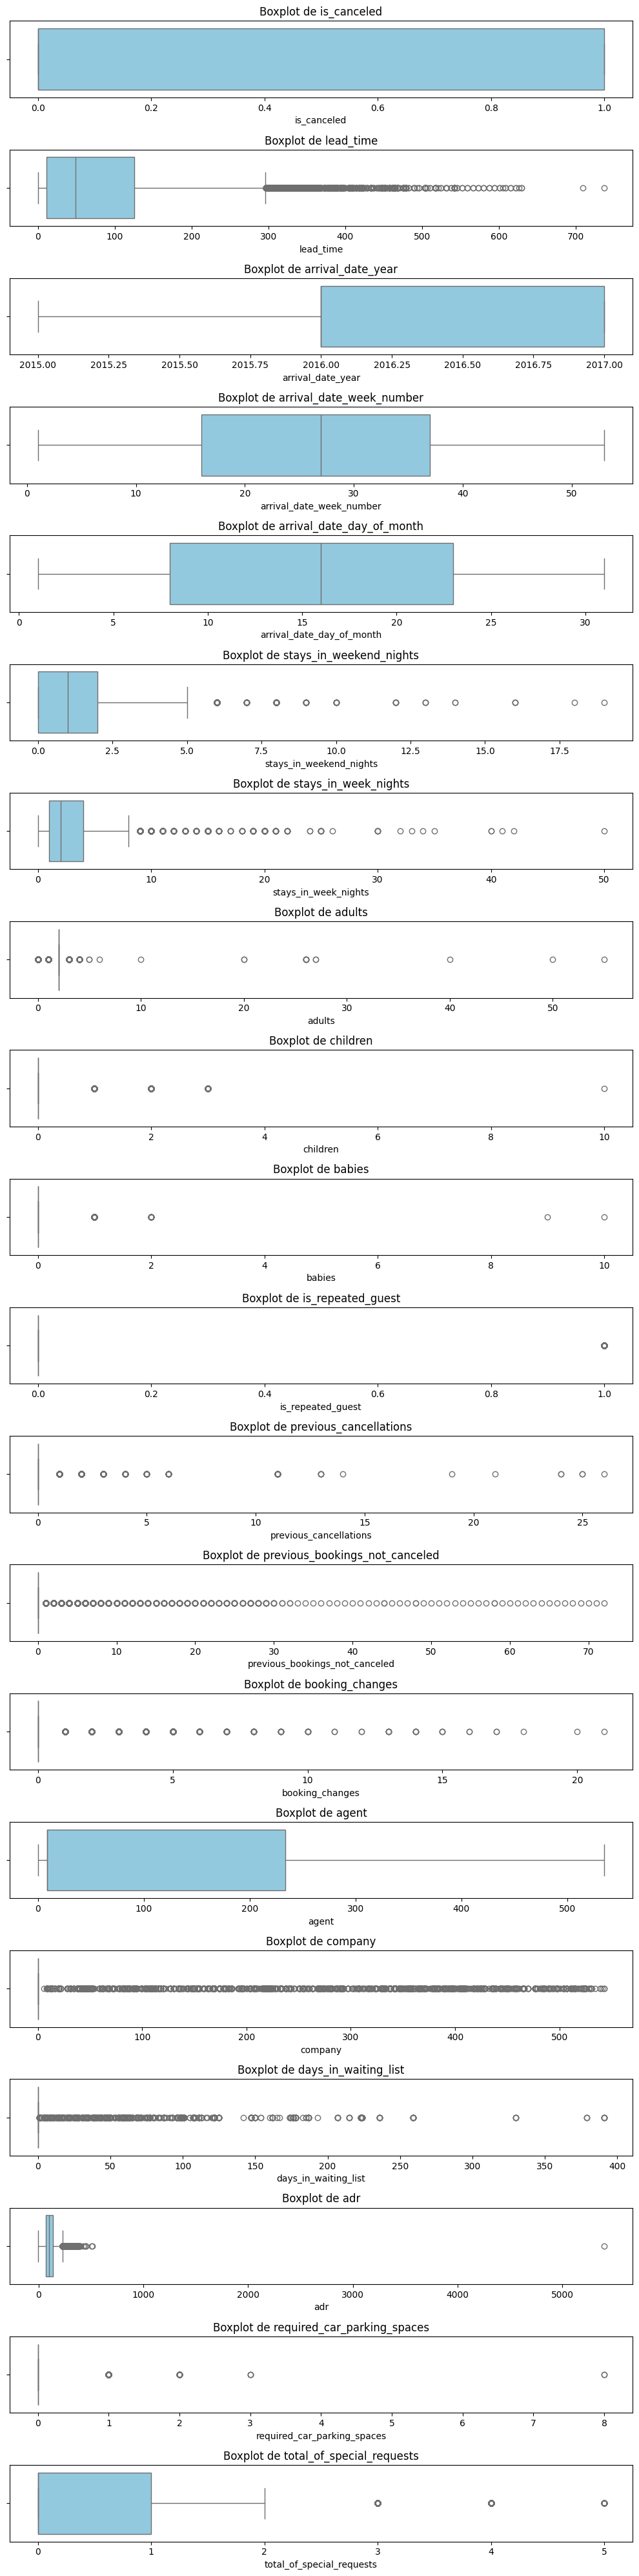

In [ ]:
# Seleccionar automáticamente todas las columnas numéricas
num_vars = df.select_dtypes(include=["int64", "float64"]).columns

# Crear subplots dinámicos
fig, axes = plt.subplots(nrows=len(num_vars), ncols=1, figsize=(10, 2*len(num_vars)))

for i, col in enumerate(num_vars):
    sns.boxplot(x=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Correlaciones numericas

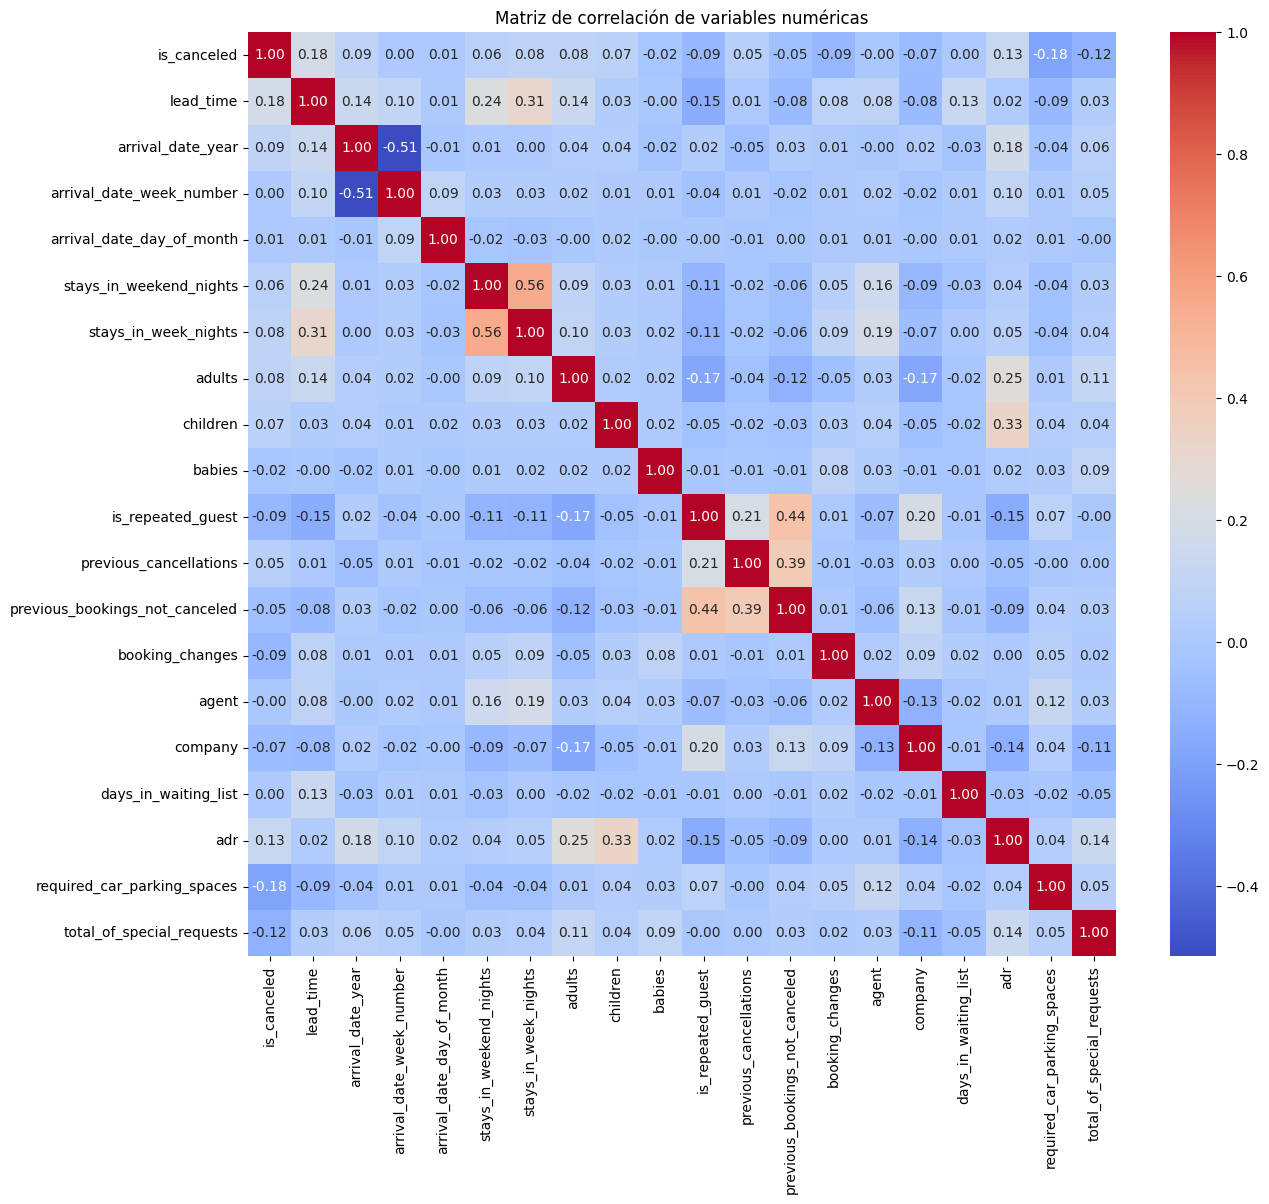

In [ ]:
# Seleccionamos solo las columnas numéricas automáticamente
numeric_df = df.select_dtypes(include='number')

# Matriz de correlación
corr_matrix = numeric_df.corr()

# Mapa de calor
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de correlación de variables numéricas')
plt.show()

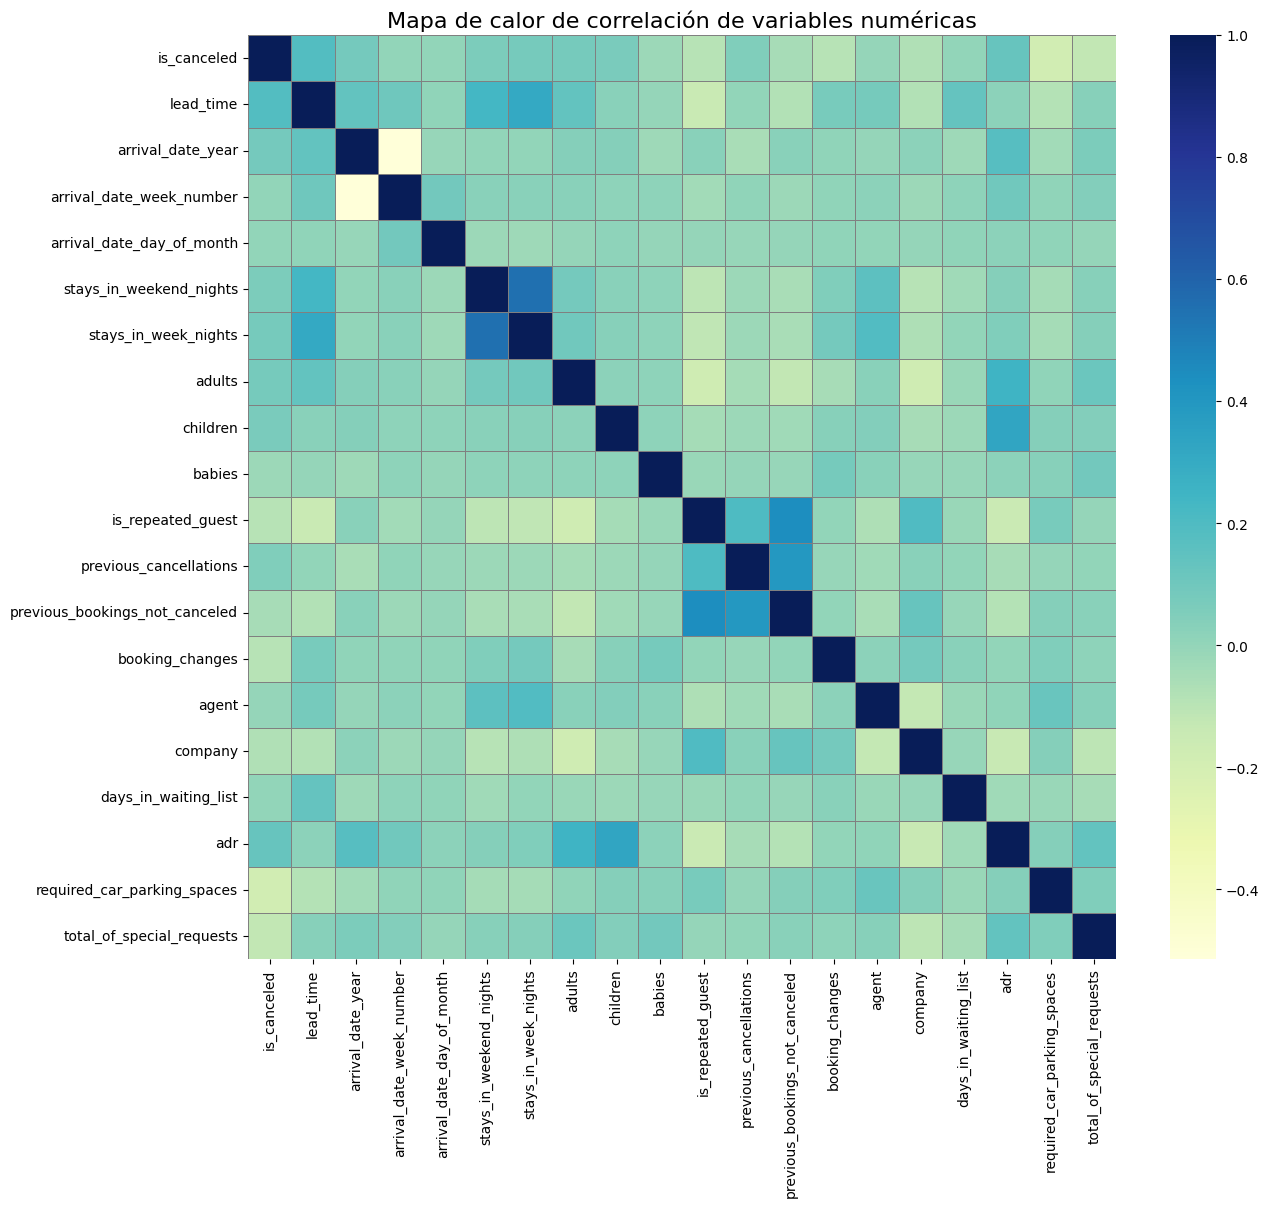

In [ ]:
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include='number')

# Calcular matriz de correlación
corr_matrix = numeric_df.corr()

# Dibujar mapa de calor más visual
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap='YlGnBu', linewidths=0.5, linecolor='gray')
plt.title('Mapa de calor de correlación de variables numéricas', fontsize=16)
plt.show()

A partir de la pregunta : ¿Cómo varía la distribución mensual de reservas entre city hotel y resort hotel,
y qué patrones de estacionalidad se observan?
Realizamos un grafico de barras para tener una respuesta anticipada.

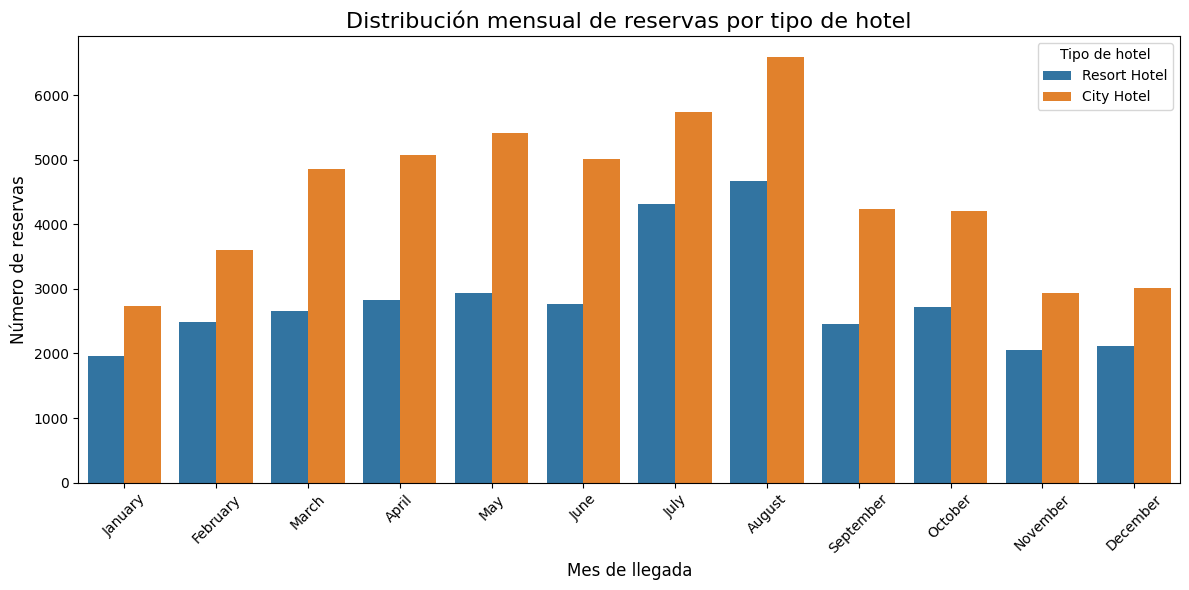

In [ ]:
# Asegurar que los meses queden en orden cronológico
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

# Gráfico de barras agrupadas
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="arrival_date_month", hue="hotel", order=month_order)

plt.title("Distribución mensual de reservas por tipo de hotel", fontsize=16)
plt.xlabel("Mes de llegada", fontsize=12)
plt.ylabel("Número de reservas", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Tipo de hotel")
plt.tight_layout()
plt.show()

¿Cómo se distribuye el lead_time (días entre la reserva y la llegada), y qué
relación tiene con la probabilidad de cancelación?


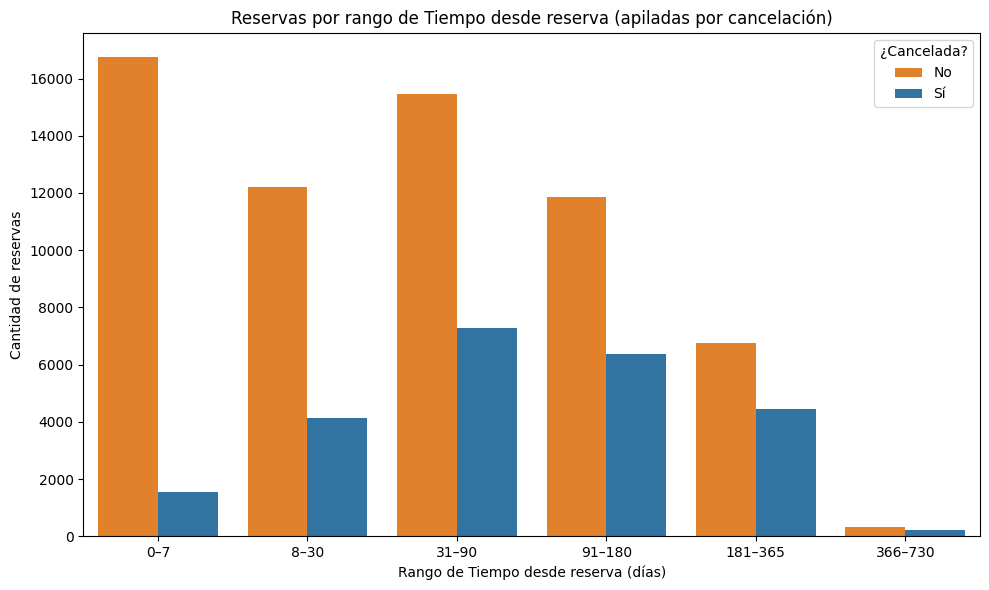

In [ ]:
df = df.copy()
df = df[df["lead_time"].notna()]

# === Definir rangos de lead_time ===
# Pensados para separar bien corto, medio y MUY anticipado
bins = [0, 7, 30, 90, 180, 365, 730]  # 0-1 semana, 8-30d, 31-90d, 91-180d, 181-365d, 366-730d
labels = [
    "0–7",
    "8–30",
    "31–90",
    "91–180",
    "181–365",
    "366–730"
]

df["lead_time_bin"] = pd.cut(df["lead_time"], bins=bins, labels=labels, right=True, include_lowest=True)
df = df[df["lead_time_bin"].notna()]  # por si hay fuera de rango

# Asegurar orden en el eje X
df["lead_time_bin"] = pd.Categorical(df["lead_time_bin"], categories=labels, ordered=True)

# === 1) Barras apiladas: volumen por rango (cancelada vs no) ===
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x="lead_time_bin",
    hue="is_canceled",
    hue_order=[0,1],                              # 0=No, 1=Sí
    palette={0: "tab:orange", 1: "tab:blue"}     # Colores fijos para no confundir
)
plt.title("Reservas por rango de Tiempo desde reserva (apiladas por cancelación)")
plt.xlabel("Rango de Tiempo desde reserva (días)")
plt.ylabel("Cantidad de reservas")
plt.legend(title="¿Cancelada?", labels=["No","Sí"])
plt.tight_layout()
plt.show()




¿Qué segmentos de mercado (market_segment) y canales de distribución
(distribution_channel) concentran más reservas y cuáles presentan mayor
proporción de cancelaciones?

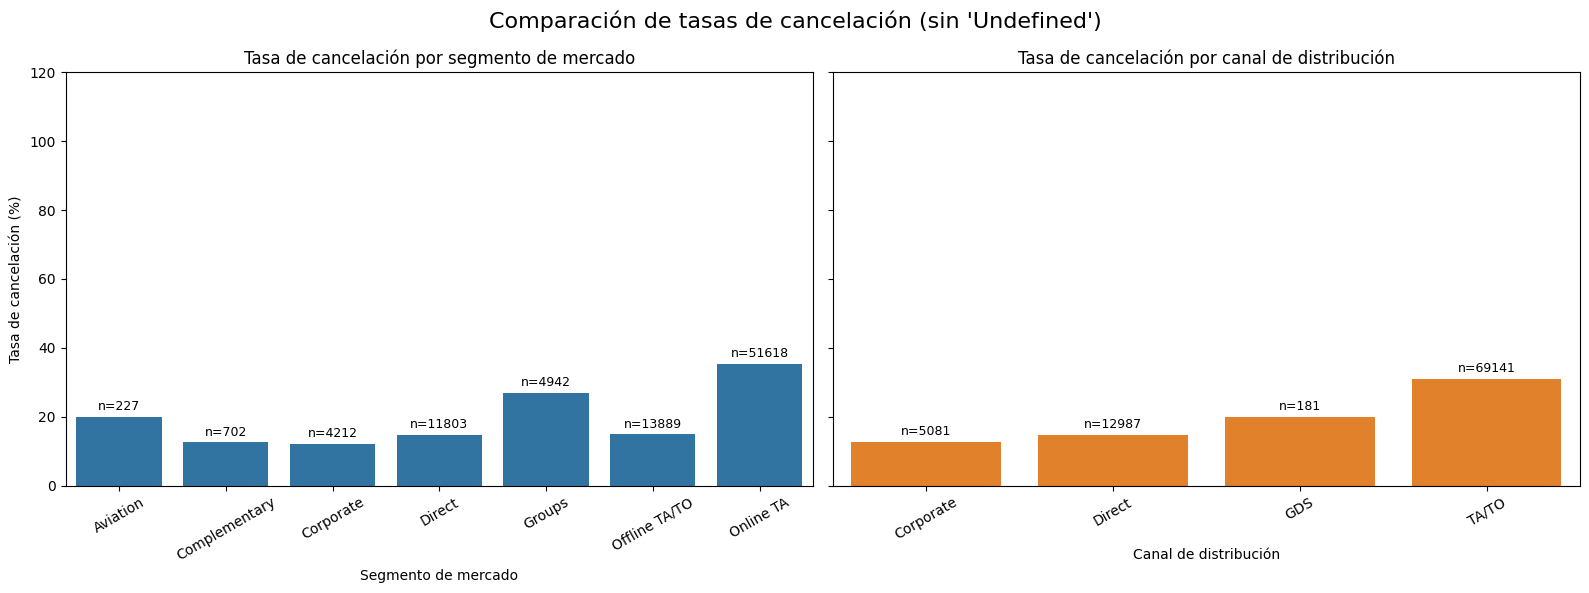

In [ ]:
# === Filtrar valores Undefined ===
df_seg = df[df["market_segment"] != "Undefined"]
df_chan = df[df["distribution_channel"] != "Undefined"]

# === Calcular tasas y cantidades por segmento y canal ===
cancel_rate_seg = (
    df_seg.groupby("market_segment")["is_canceled"]
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={"mean":"tasa_cancelacion","count":"n_reservas"})
)
cancel_rate_seg["tasa_cancelacion"] *= 100

cancel_rate_chan = (
    df_chan.groupby("distribution_channel")["is_canceled"]
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={"mean":"tasa_cancelacion","count":"n_reservas"})
)
cancel_rate_chan["tasa_cancelacion"] *= 100

# === Crear figura con 2 subplots lado a lado ===
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# --- Panel 1: market_segment ---
sns.barplot(
    data=cancel_rate_seg,
    x="market_segment", y="tasa_cancelacion",
    color="tab:blue", ax=axes[0]
)
axes[0].set_title("Tasa de cancelación por segmento de mercado")
axes[0].set_xlabel("Segmento de mercado")
axes[0].set_ylabel("Tasa de cancelación (%)")
axes[0].set_ylim(0, 120)
axes[0].tick_params(axis='x', rotation=30)

# Anotar valores de cantidad de reservas
for i, row in cancel_rate_seg.iterrows():
    axes[0].text(
        i, row["tasa_cancelacion"] + 2,
        f'n={row["n_reservas"]}',
        ha="center", fontsize=9, color="black"
    )

# --- Panel 2: distribution_channel ---
sns.barplot(
    data=cancel_rate_chan,
    x="distribution_channel", y="tasa_cancelacion",
    color="tab:orange", ax=axes[1]
)
axes[1].set_title("Tasa de cancelación por canal de distribución")
axes[1].set_xlabel("Canal de distribución")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=30)

# Anotar valores de cantidad de reservas
for i, row in cancel_rate_chan.iterrows():
    axes[1].text(
        i, row["tasa_cancelacion"] + 2,
        f'n={row["n_reservas"]}',
        ha="center", fontsize=9, color="black"
    )

plt.suptitle("Comparación de tasas de cancelación (sin 'Undefined')", fontsize=16)
plt.tight_layout()
plt.show()


¿Qué países de origen generan mayor volumen de reservas y cuál es su tasa
relativa de cancelación?

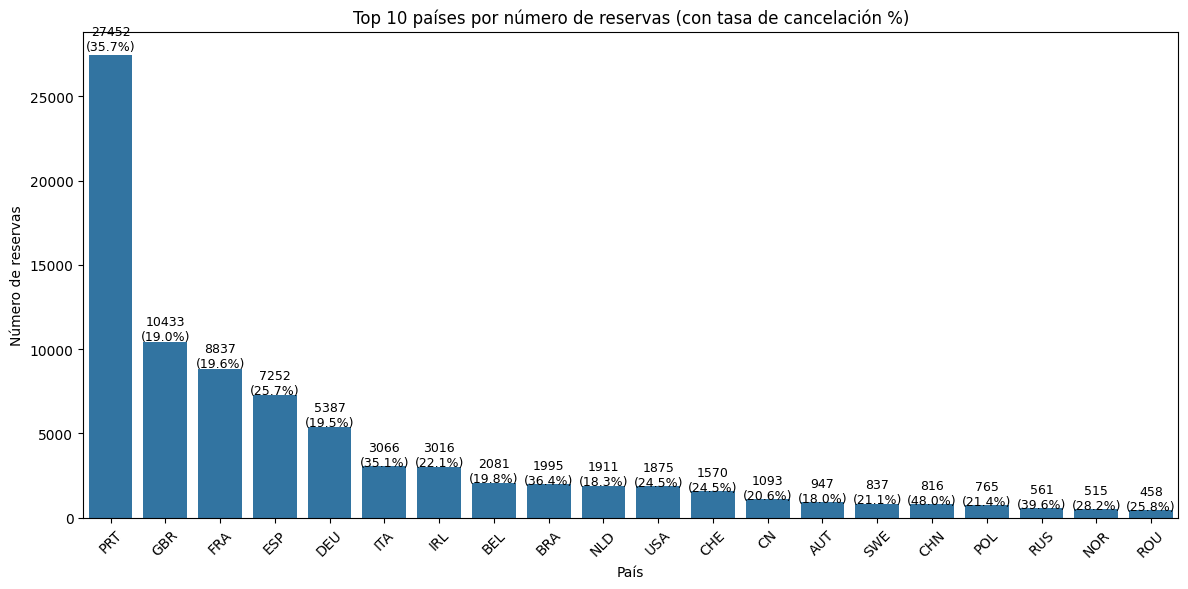

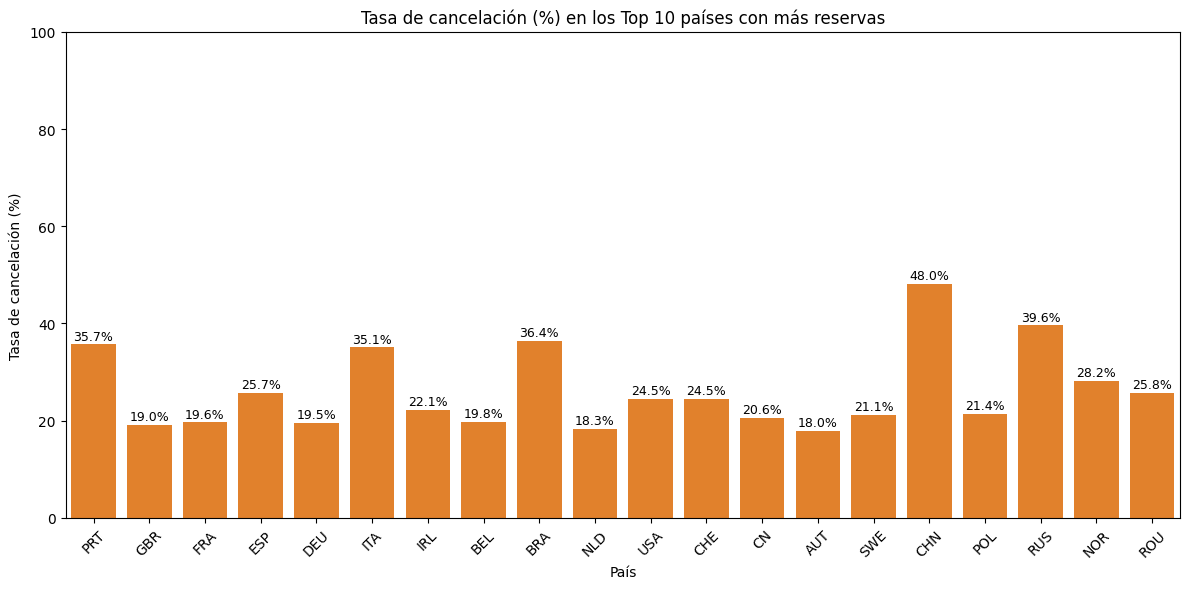

In [ ]:
# === Agrupar por país ===
country_stats = (
    df.groupby("country")["is_canceled"]
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={"mean":"tasa_cancelacion","count":"n_reservas"})
)
country_stats["tasa_cancelacion"] *= 100  # convertir a %

# --- Top 10 países por número de reservas ---
top_countries = country_stats.sort_values("n_reservas", ascending=False).head(20)

# --- 1) Gráfico: Número de reservas + tasa de cancelación en etiquetas ---
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_countries,
    x="country", y="n_reservas",
    color="tab:blue"
)

# Etiquetas arriba con reservas y tasa
for i, row in enumerate(top_countries.itertuples()):
    plt.text(i, row.n_reservas + (row.n_reservas*0.01),
             f'{row.n_reservas}\n({row.tasa_cancelacion:.1f}%)',
             ha="center", fontsize=9)

plt.title("Top 10 países por número de reservas (con tasa de cancelación %)")
plt.xlabel("País")
plt.ylabel("Número de reservas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 2) Gráfico: Tasa de cancelación ---
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_countries,
    x="country", y="tasa_cancelacion",
    color="tab:orange"
)

# Etiquetas arriba
for i, row in enumerate(top_countries.itertuples()):
    plt.text(i, row.tasa_cancelacion + 1,
             f'{row.tasa_cancelacion:.1f}%', ha="center", fontsize=9)

plt.title("Tasa de cancelación (%) en los Top 10 países con más reservas")
plt.xlabel("País")
plt.ylabel("Tasa de cancelación (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Cómo se distribuye la duración de la estancia y qué diferencias existen entre city hotel y resort hotel?

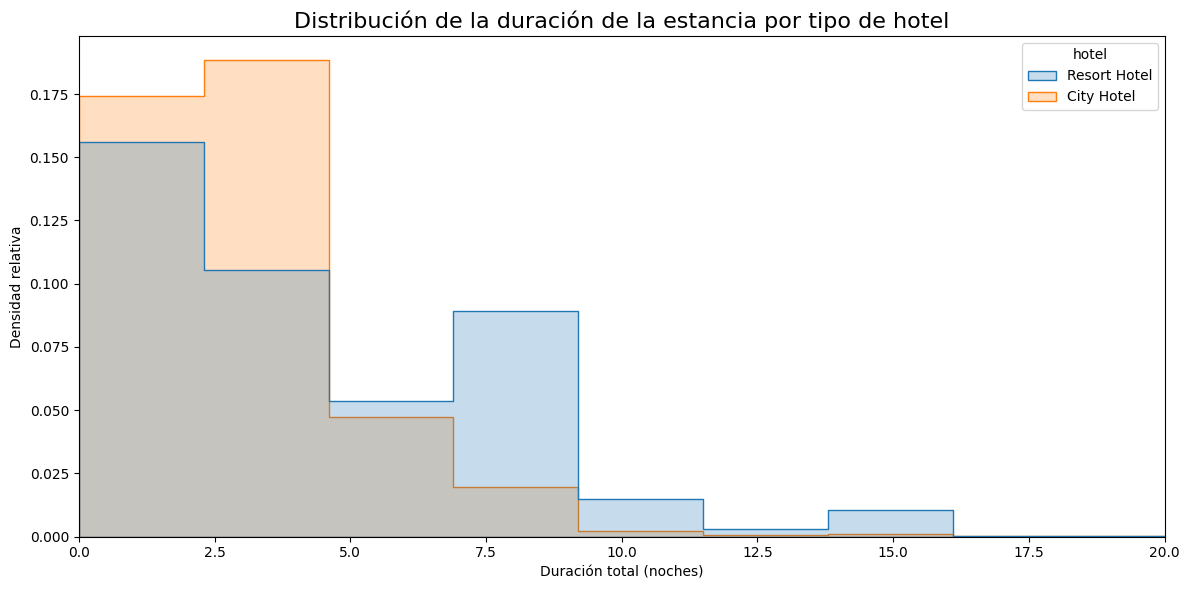

In [ ]:
# Crear columna de duración total
df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Histograma comparativo
plt.figure(figsize=(12,6))
sns.histplot(
    data=df,
    x="total_stay",
    hue="hotel",
    bins=30,
    kde=False,
    element="step",
    stat="density",   # proporciones en vez de conteos
    common_norm=False # cada hotel se normaliza por separado
)

plt.title("Distribución de la duración de la estancia por tipo de hotel", fontsize=16)
plt.xlabel("Duración total (noches)")
plt.ylabel("Densidad relativa")
plt.xlim(0, 20)  # limitar a estancias comunes
plt.tight_layout()
plt.show()

¿Cuál es la evolución del ADR (tarifa diaria promedio) por mes y por tipo de
hotel, y cómo se refleja en temporada alta vs baja?

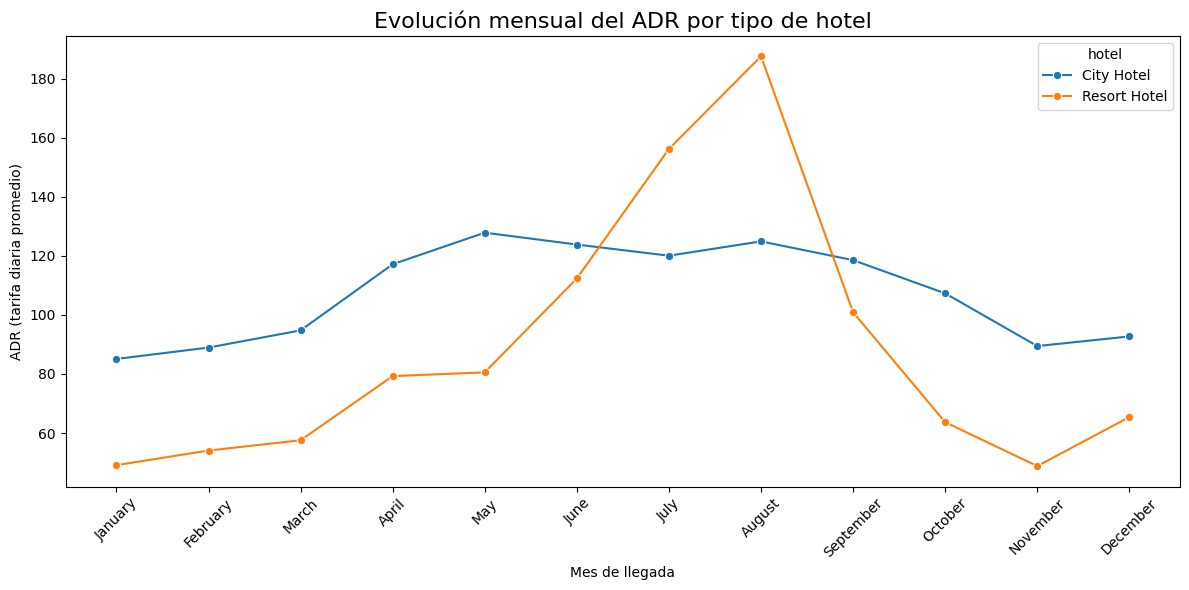

In [ ]:
# Asegurar orden correcto de meses
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

# Agrupar por mes y hotel para calcular ADR promedio
adr_monthly = (
    df.groupby(["arrival_date_month","hotel"])["adr"]
      .mean()
      .reset_index()
)

# Convertir a categórico ordenado para respetar orden cronológico
adr_monthly["arrival_date_month"] = pd.Categorical(
    adr_monthly["arrival_date_month"], categories=month_order, ordered=True
)

# Gráfico de líneas
plt.figure(figsize=(12,6))
sns.lineplot(
    data=adr_monthly,
    x="arrival_date_month", y="adr",
    hue="hotel", marker="o"
)

plt.title("Evolución mensual del ADR por tipo de hotel", fontsize=16)
plt.xlabel("Mes de llegada")
plt.ylabel("ADR (tarifa diaria promedio)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

¿Cuál es la proporción de huéspedes según composición (adultos, niños y
bebés) y cómo varía entre meses?

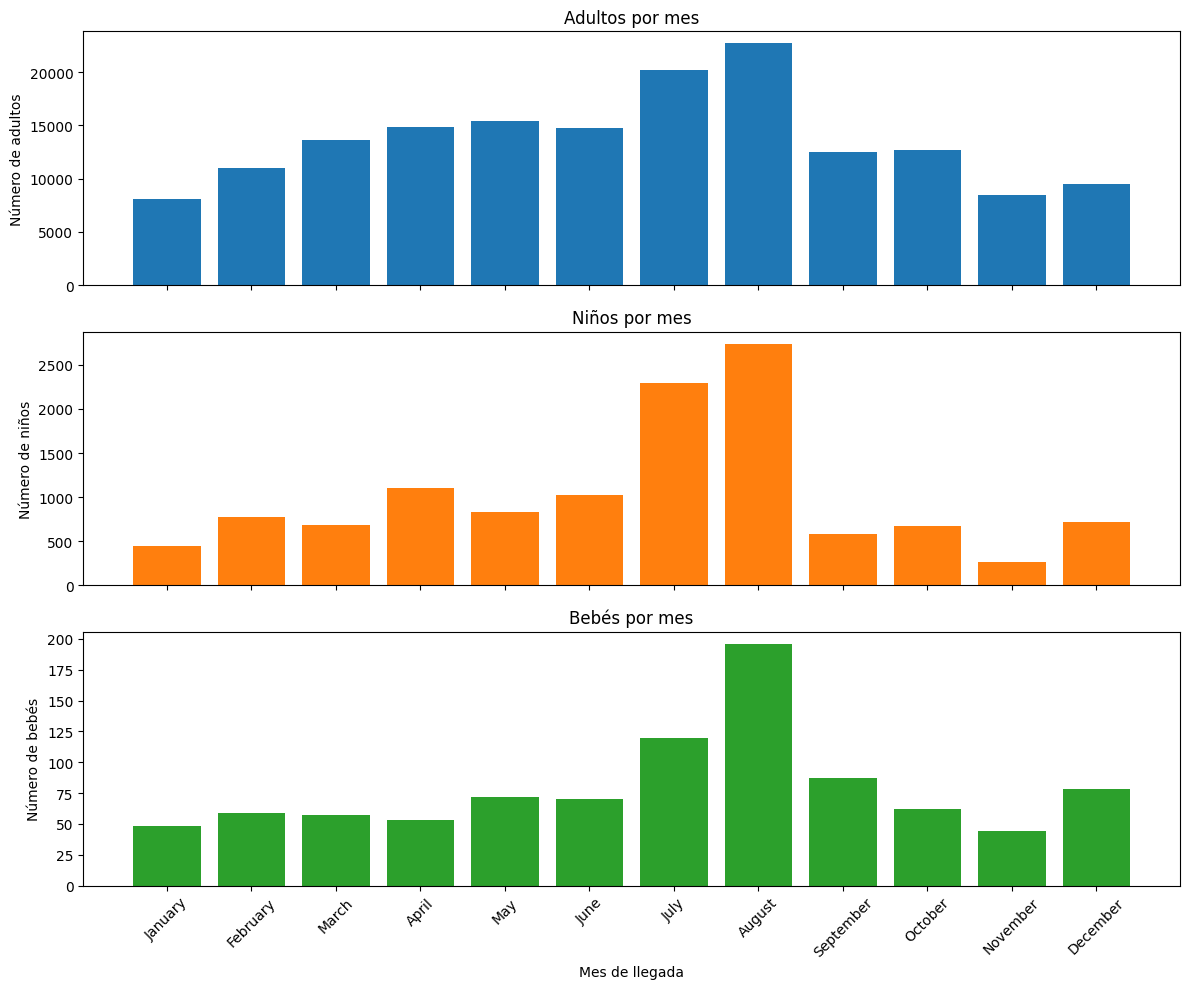

In [ ]:
# Orden cronológico de meses
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

# Agrupar por mes
guests_monthly = (
    df.groupby("arrival_date_month")[["adults","children","babies"]]
      .sum()
      .reindex(month_order)
)

# Crear subplots
fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True)

# --- Adultos ---
axes[0].bar(guests_monthly.index, guests_monthly["adults"], color="tab:blue")
axes[0].set_title("Adultos por mes")
axes[0].set_ylabel("Número de adultos")

# --- Niños ---
axes[1].bar(guests_monthly.index, guests_monthly["children"], color="tab:orange")
axes[1].set_title("Niños por mes")
axes[1].set_ylabel("Número de niños")

# --- Bebés ---
axes[2].bar(guests_monthly.index, guests_monthly["babies"], color="tab:green")
axes[2].set_title("Bebés por mes")
axes[2].set_ylabel("Número de bebés")
axes[2].set_xlabel("Mes de llegada")

# Ajustar etiquetas
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

¿Qué proporción de reservas corresponde a clientes recurrentes
(is_repeated_guest) y cómo impacta en las cancelaciones?

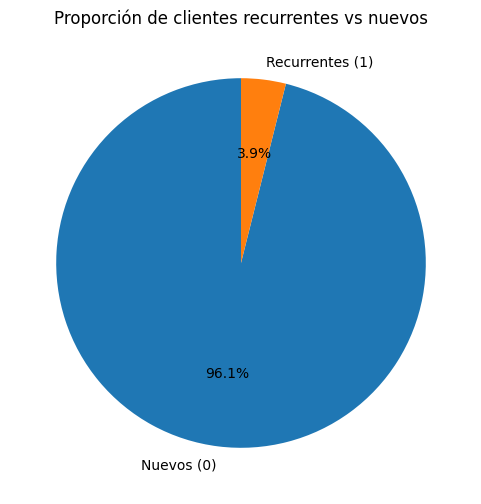

C:\Users\usuario\AppData\Local\Temp\ipykernel_8980\1524090863.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancel_rate, x="is_repeated_guest", y="is_canceled", palette="Set2")


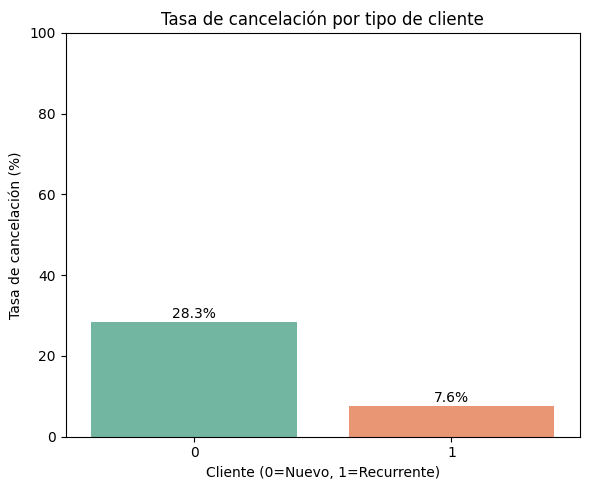

In [ ]:
# --- 1) Proporción de clientes recurrentes vs nuevos ---
repeated_counts = df["is_repeated_guest"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(repeated_counts, labels=["Nuevos (0)", "Recurrentes (1)"], 
        autopct="%1.1f%%", colors=["tab:blue","tab:orange"], startangle=90)
plt.title("Proporción de clientes recurrentes vs nuevos")
plt.show()

# --- 2) Tasa de cancelación por tipo de cliente ---
cancel_rate = (
    df.groupby("is_repeated_guest")["is_canceled"]
      .mean()
      .reset_index()
)
cancel_rate["is_canceled"] *= 100  # convertir a %

plt.figure(figsize=(6,5))
sns.barplot(data=cancel_rate, x="is_repeated_guest", y="is_canceled", palette="Set2")
plt.title("Tasa de cancelación por tipo de cliente")
plt.xlabel("Cliente (0=Nuevo, 1=Recurrente)")
plt.ylabel("Tasa de cancelación (%)")

# Etiquetas arriba
for i, row in cancel_rate.iterrows():
    plt.text(i, row.is_canceled + 1, f"{row.is_canceled:.1f}%", ha="center")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
# Columnas categóricas primeras 10
cat_cols = df.select_dtypes(include=['object']).columns

# Tomar solo las primeras 10 columnas (o menos si hay menos de 10)
primeras_10 = cat_cols[:10]

# Mostrar cada columna y su distribución de valores
for col in primeras_10:
    print(f"\nColumna: {col}")
    display(df[col].value_counts())




Columna: hotel


hotel
City Hotel      53428
Resort Hotel    33967
Name: count, dtype: int64


Columna: arrival_date_month


arrival_date_month
August       11257
July         10056
May           8355
April         7908
June          7765
March         7513
October       6934
September     6690
February      6098
December      5131
November      4995
January       4693
Name: count, dtype: int64


Columna: meal


meal
BB           67977
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64


Columna: country


country
PRT    27452
GBR    10433
FRA     8837
ESP     7252
DEU     5387
       ...  
MRT        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 178, dtype: int64


Columna: market_segment


market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11803
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64


Columna: distribution_channel


distribution_channel
TA/TO        69141
Direct       12987
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64


Columna: reserved_room_type


reserved_room_type
A    56552
D    17398
E     6049
F     2823
G     2052
B      999
C      914
H      596
L        6
P        6
Name: count, dtype: int64


Columna: assigned_room_type


assigned_room_type
A    46313
D    22432
E     7195
F     3627
G     2498
C     2164
B     1820
H      706
I      357
K      276
P        6
L        1
Name: count, dtype: int64


Columna: deposit_type


deposit_type
No Deposit    86250
Non Refund     1038
Refundable      107
Name: count, dtype: int64


Columna: customer_type


customer_type
Transient          71985
Transient-Party    11727
Contract            3139
Group                544
Name: count, dtype: int64

In [46]:
# Columnas categóricas 1
cat_cols = df.select_dtypes(include=['object']).columns

# Excluir reservation_status_date
cat_cols_sin_fecha = [col for col in cat_cols if col != 'reservation_status_date']

# Tomar las columnas de la 11 a la 20 (máximo 10)
siguientes_10 = cat_cols_sin_fecha[10:20]

# Mostrar cada columna y su distribución de valores
for col in siguientes_10:
    print(f"\nColumna: {col}")
    display(df[col].value_counts())



Columna: reservation_status


reservation_status
Check-Out    63370
Canceled     23011
No-Show       1014
Name: count, dtype: int64

CONTEO DE RESERVAS POR AÑO, MES Y DIA DE LA SEMANA

In [92]:
# Convertir a datetime 1
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Conteo por año
print("\nConteo por año:")
display(df['reservation_status_date'].dt.year.value_counts().sort_index())

# Conteo por mes
print("\nConteo por mes:")
display(df['reservation_status_date'].dt.month.value_counts().sort_index())

# Conteo por día de la semana
print("\nConteo por día de la semana (0=Lunes, 6=Domingo):")
display(df['reservation_status_date'].dt.dayofweek.value_counts().sort_index())



Conteo por año:


reservation_status_date
2014       12
2015    13546
2016    43927
2017    29910
Name: count, dtype: int64


Conteo por mes:


reservation_status_date
1     6490
2     7054
3     8158
4     7831
5     8197
6     7366
7     8839
8     9268
9     6917
10    6858
11    5634
12    4783
Name: count, dtype: int64


Conteo por día de la semana (0=Lunes, 6=Domingo):


reservation_status_date
0    13196
1    11701
2    12178
3    13414
4    13076
5    10697
6    13133
Name: count, dtype: int64

CALCULO PARA CONOCER LOS AÑOS Y LOS MESES IMPLICADOS

In [93]:
# Año mínimo y máximo
print("Rango de años:", df['arrival_date_year'].min(), "-", df['arrival_date_year'].max())

# Meses distintos
print("Meses presentes:", df['arrival_date_month'].unique())


Rango de años: 2015 - 2017
Meses presentes: ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']


Algoritmos de clasificacion

CLASIFICACION - KNN

Iniciando búsqueda de hiperparámetros para KNN...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

¡Búsqueda finalizada!
Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'distance'}
Mejor accuracy (cross-validation): 0.8431

🎯 Accuracy en test: 0.8477


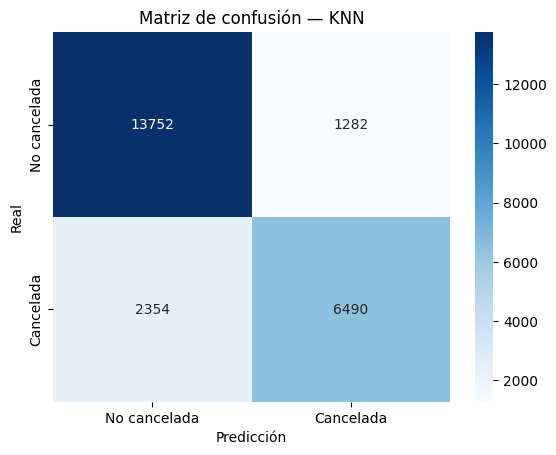

In [2]:
# ============================================================
# MODELO KNN — CLASIFICACIÓN DE CANCELACIONES HOTELERAS
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# ---------------------------------------------
# 1️⃣ Carga y selección de columnas
# ---------------------------------------------
df = pd.read_csv("data/hotel_bookings.csv")

features = [
    "hotel",
    "lead_time",
    "adr",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults",
    "children",
    "babies",
    "total_of_special_requests",
    "customer_type",
    "deposit_type",
    "market_segment",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces"
]
target = "is_canceled"

# Filtrar columnas relevantes
df = df[features + [target]].dropna()

# ---------------------------------------------
# 2️⃣ Codificación de variables categóricas
# ---------------------------------------------
df["hotel"] = df["hotel"].map({"City Hotel": 0, "Resort Hotel": 1})

# Variables categóricas para one-hot encoding
categoricas = ["customer_type", "deposit_type", "market_segment"]

df = pd.get_dummies(df, columns=categoricas, drop_first=True)

# ---------------------------------------------
# 3️⃣ Separación de datos
# ---------------------------------------------
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------
# 4️⃣ Escalado
# ---------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------
# 5️⃣ Búsqueda de hiperparámetros
# ---------------------------------------------
print("Iniciando búsqueda de hiperparámetros para KNN...")

knn_base = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 19],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n¡Búsqueda finalizada!")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor accuracy (cross-validation): {grid_search.best_score_:.4f}")

# ---------------------------------------------
# 6️⃣ Evaluación en conjunto de prueba
# ---------------------------------------------
y_pred = grid_search.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy en test: {acc:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No cancelada', 'Cancelada'],
    yticklabels=['No cancelada', 'Cancelada']
)
plt.title("Matriz de confusión — KNN")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

CLASIFICACION - BAYES GAUSSIANO

Buscando el mejor 'var_smoothing'...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

✅ Mejor parámetro encontrado: {'var_smoothing': np.float64(0.01)}
Mejor score (accuracy) de CV: 0.6018

--- Resultados del Modelo Optimizado ---
Accuracy (en Test): 0.6039

Matriz de confusión:
[[6726 8308]
 [1150 7694]]


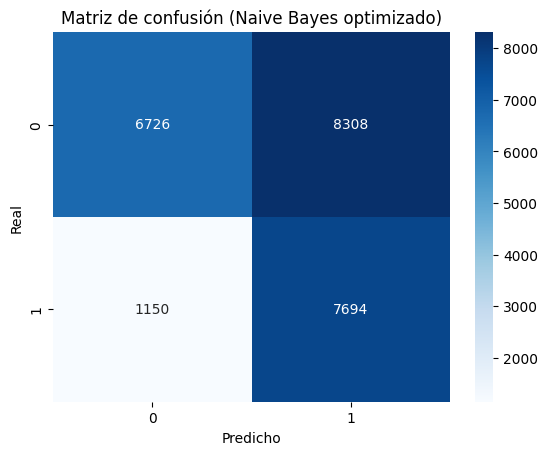

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/hotel_bookings.csv")
# ==============================
# 1️⃣ Variables de entrada y salida
# ==============================
features = [
    "hotel", "lead_time", "adr",
    "stays_in_week_nights", "stays_in_weekend_nights",
    "adults", "children", "babies",
    "total_of_special_requests",
    "customer_type", "deposit_type", "market_segment",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces"
]
target = "is_canceled"

# ==============================
# 2️⃣ Preparación de los datos
# ==============================
# Crear subconjunto de datos
data = df[features + [target]].dropna()

# Variables categóricas a codificar
categoricas = ["hotel", "customer_type", "deposit_type", "market_segment"]

# Convertir a numéricas con get_dummies
data_encoded = pd.get_dummies(data, columns=categoricas, drop_first=True)

X = data_encoded.drop(columns=[target])
y = data_encoded[target]

# ==============================
# 3️⃣ División entrenamiento/prueba
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 4️⃣ Búsqueda de hiperparámetros (GridSearchCV)
# ==============================
param_grid_nb = {'var_smoothing': np.logspace(-9, -2, num=100)}

nb_grid = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("Buscando el mejor 'var_smoothing'...")
nb_grid.fit(X_train_scaled, y_train)

print(f"\n✅ Mejor parámetro encontrado: {nb_grid.best_params_}")
print(f"Mejor score (accuracy) de CV: {nb_grid.best_score_:.4f}")

# ==============================
# 5️⃣ Evaluación del modelo final
# ==============================
y_pred = nb_grid.predict(X_test_scaled)

print("\n--- Resultados del Modelo Optimizado ---")
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (en Test): {acc:.4f}")

print("\nMatriz de confusión:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión (Naive Bayes optimizado)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


CLASIFICACION - ARBOL DE DECISION

Accuracy: 0.808

Matriz de confusión:
[[13935  1099]
 [ 3479  5365]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.800     0.927     0.859     15034
           1      0.830     0.607     0.701      8844

    accuracy                          0.808     23878
   macro avg      0.815     0.767     0.780     23878
weighted avg      0.811     0.808     0.800     23878



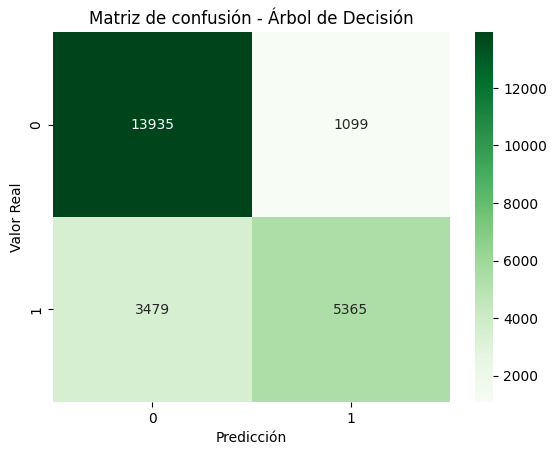

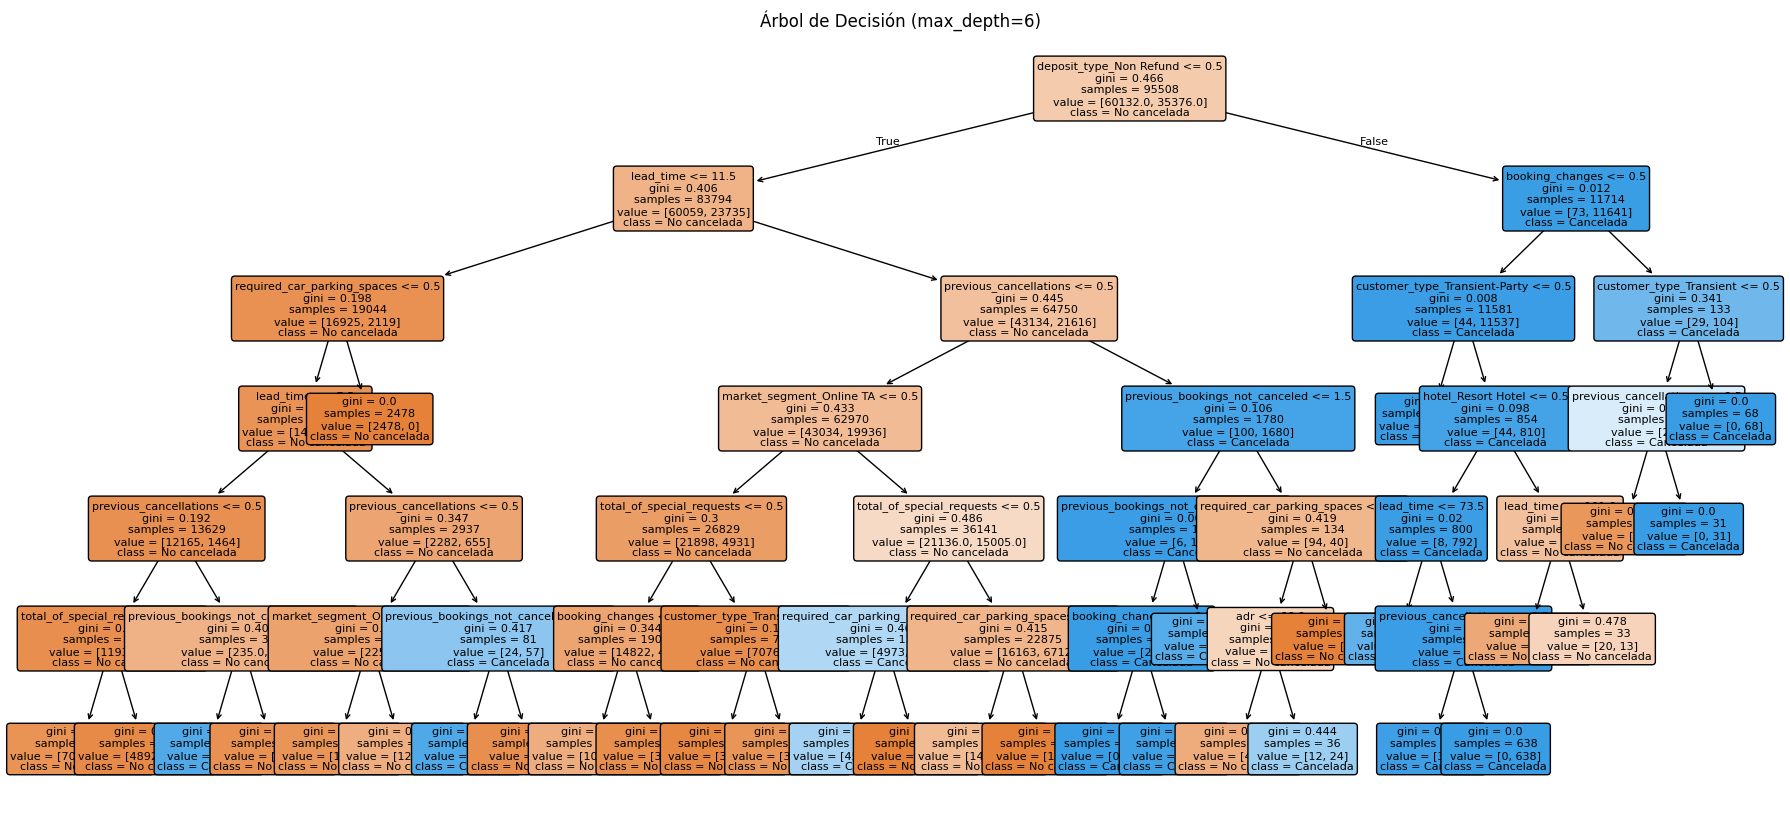

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import seaborn as sns

# ====================================
# 1️⃣ Variables y preparación de datos
# ====================================
features = [
    "hotel", "lead_time", "adr",
    "stays_in_week_nights", "stays_in_weekend_nights",
    "adults", "children", "babies",
    "total_of_special_requests",
    "customer_type", "deposit_type", "market_segment",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces"
]
target = "is_canceled"

# Subconjunto y eliminación de nulos
data = df[features + [target]].dropna()

# Variables categóricas
categoricas = ["hotel", "customer_type", "deposit_type", "market_segment"]

# Codificación one-hot (sin primera categoría para evitar colinealidad)
data_encoded = pd.get_dummies(data, columns=categoricas, drop_first=True)

X = data_encoded.drop(columns=[target])
y = data_encoded[target]

# ====================================
# 2️⃣ División entrenamiento / prueba
# ====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ====================================
# 3️⃣ Entrenamiento del modelo
# ====================================
arbol = DecisionTreeClassifier(
    criterion="gini",        # también podés probar "entropy"
    max_depth=6,             # controla la complejidad del árbol
    min_samples_split=50,    # evita sobreajuste
    min_samples_leaf=20,     # evita hojas con muy pocos casos
    random_state=42
)

arbol.fit(X_train, y_train)

# ====================================
# 4️⃣ Evaluación del modelo
# ====================================
y_pred = arbol.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, digits=3))

# Heatmap de la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

# ====================================
# 5️⃣ Visualización del árbol
# ====================================
plt.figure(figsize=(22, 10))
plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=["No cancelada", "Cancelada"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de Decisión (max_depth=6)")
plt.show()


CLASIFICACION - RANDOM FOREST

🚀 Buscando los mejores parámetros para Random Forest...
Fitting 3 folds for each of 60 candidates, totalling 180 fits

✅ Mejores hiperparámetros encontrados:
{'n_estimators': 500, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}

🎯 Precisión final del modelo optimizado: 0.8504

📋 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89     15034
           1       0.86      0.71      0.78      8844

    accuracy                           0.85     23878
   macro avg       0.85      0.82      0.83     23878
weighted avg       0.85      0.85      0.85     23878



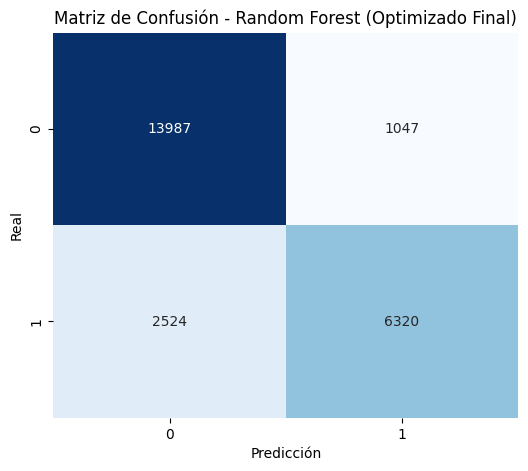

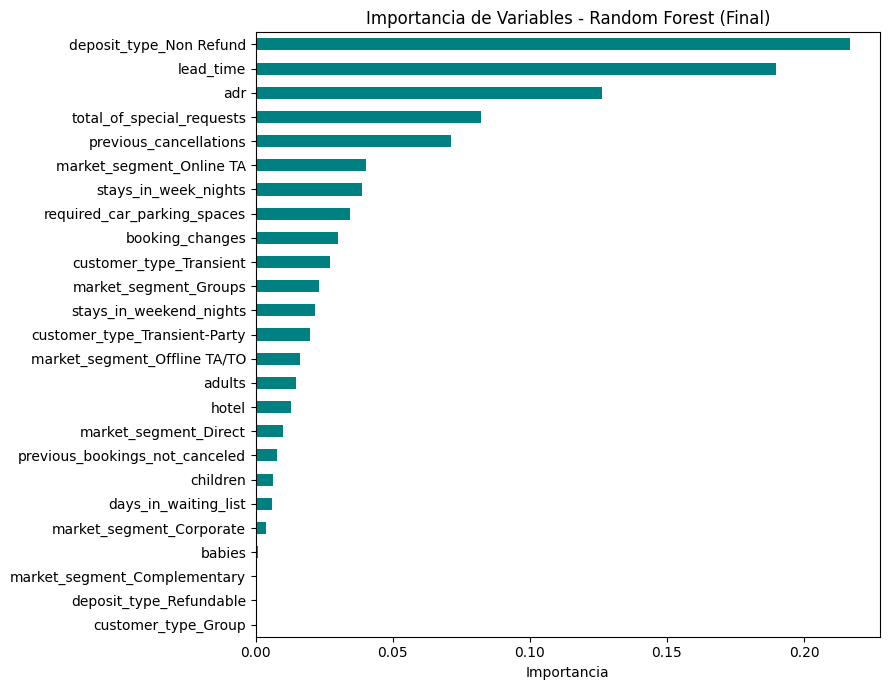

✅ Modelo de clasificación guardado correctamente como modelo_clasificacion.pkl


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ======================================================
# 1️⃣ Cargar los datos
# ======================================================
data = pd.read_csv("data/hotel_bookings.csv")

# ======================================================
# 2️⃣ Variables a usar (combinadas según tus listas)
# ======================================================
features = [
    "hotel", "lead_time", "adr",
    "stays_in_week_nights", "stays_in_weekend_nights",
    "adults", "children", "babies",
    "total_of_special_requests", "customer_type",
    "deposit_type", "market_segment",
    "previous_cancellations", "previous_bookings_not_canceled",
    "booking_changes", "days_in_waiting_list",
    "required_car_parking_spaces"
]
target = "is_canceled"

# ======================================================
# 3️⃣ Limpieza y codificación
# ======================================================
df_final = data[features + [target]].dropna()
df_final["hotel"] = df_final["hotel"].map({"City Hotel": 0, "Resort Hotel": 1})
df_final = pd.get_dummies(
    df_final,
    columns=["customer_type", "deposit_type", "market_segment"],
    drop_first=True
)

# ======================================================
# 4️⃣ División del dataset
# ======================================================
X = df_final.drop(columns=[target])
y = df_final[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================================
# 5️⃣ Escalado de variables
# ======================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ======================================================
# 6️⃣ Búsqueda optimizada de hiperparámetros
# ======================================================
rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=60,
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("🚀 Buscando los mejores parámetros para Random Forest...")
random_search.fit(X_train_scaled, y_train)

best_rf = random_search.best_estimator_
print("\n✅ Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

# ======================================================
# 7️⃣ Evaluación final
# ======================================================
y_pred = best_rf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\n🎯 Precisión final del modelo optimizado: {acc:.4f}")
print("\n📋 Reporte de clasificación:")
print(classification_report(y_test, y_pred))

# ======================================================
# 8️⃣ Visualización
# ======================================================
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Random Forest (Optimizado Final)")
plt.show()

# ======================================================
# 9️⃣ Importancia de variables
# ======================================================
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9,7))
importances.plot(kind='barh', color='teal')
plt.title("Importancia de Variables - Random Forest (Final)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

import pickle

modelo_clasificacion = {
    "model": best_rf,   # ✅ este es tu modelo final entrenado
    "scaler_X": scaler, # ✅ este es tu escalador real
    "features": X.columns.tolist()  # ✅ las columnas finales de entrenamiento
}

with open('modelo_clasificacion.pkl', 'wb') as f:
    pickle.dump(modelo_clasificacion, f)

print("✅ Modelo de clasificación guardado correctamente como modelo_clasificacion.pkl")



REGRESION - SVM (Candidato)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11112\1854901255.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_cols)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_11112\1854901255.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_cols)


SVR (base) -> R²: 0.676 | RMSE: 455.4

Mejores hiperparámetros: {'C': 10, 'epsilon': 0.05, 'gamma': 0.3}
SVR (best) -> R²: 0.860 | RMSE: 299.2


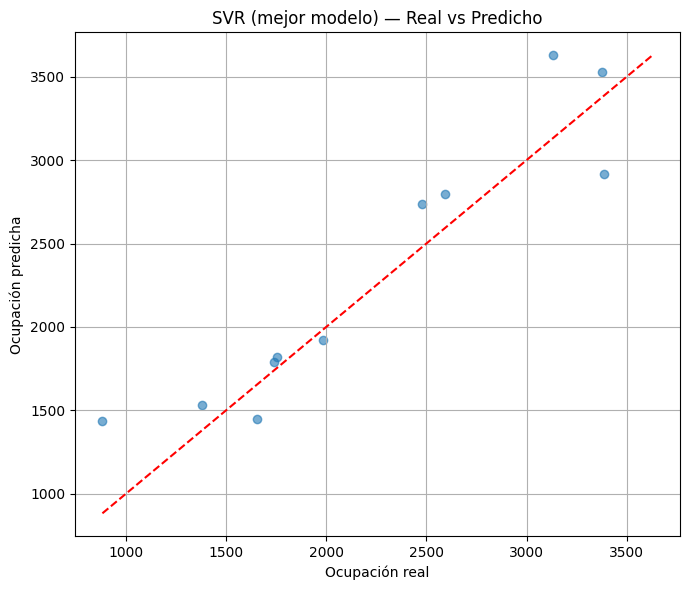

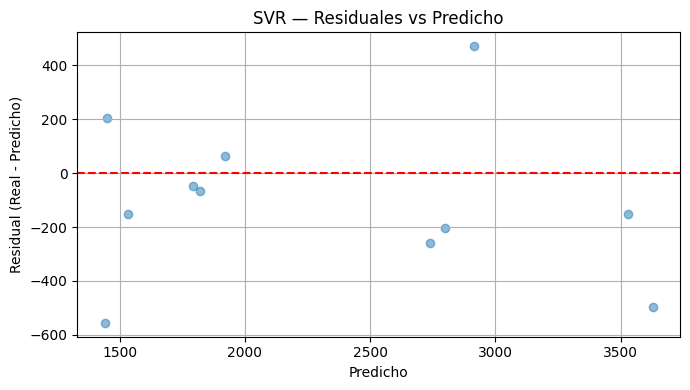


🎯 Predicción SVR (ejemplo manual): 1954 reservas/mes

💾 Modelo guardado correctamente como 'modelo_regresion.pkl'


In [25]:
# ============================================================
# SVM REGRESIÓN (SVR) COMPLETO — Ocupación mensual por hotel
# ============================================================

# 0) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# ---------------------------------------
# 1) CARGA Y PREPARACIÓN DEL DATASET BASE
# ---------------------------------------


# Asegurar numéricos en columnas que vamos a promediar
num_cols = [
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "total_of_special_requests"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Orden natural de meses (por si viene como texto)
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"],
                                          categories=month_order, ordered=True)

# 2) Construir dataset mensual (target = ocupación mensual, conteo de reservas)
group_cols = ["hotel","arrival_date_year","arrival_date_month"]

ocup = (
    df.groupby(group_cols)
      .size()
      .reset_index(name="ocupacion")
)

agg = (
    df.groupby(group_cols)
      .agg({
          "lead_time":"mean",
          "adr":"mean",
          "stays_in_week_nights":"mean",
          "stays_in_weekend_nights":"mean",
          "total_of_special_requests":"mean"
      })
      .reset_index()
)

data = ocup.merge(agg, on=group_cols, how="inner")

# Codificaciones generales
data["month_num"] = data["arrival_date_month"].cat.codes + 1
data["arrival_date_year"] = pd.to_numeric(data["arrival_date_year"], errors="coerce")

# hotel -> 0/1 (macro, no micro variables de cliente)
data["hotel"] = data["hotel"].map({"City Hotel":0, "Resort Hotel":1})

# ---------------------------
# 3) DEFINIR FEATURES Y TARGET
# ---------------------------
# Variables GENERALES (macro) coherentes con ocupación mensual
features = [
    "hotel","arrival_date_year","month_num",
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "total_of_special_requests"
]
target = "ocupacion"

model_df = data[features + [target]].dropna().copy()
X = model_df[features]
y = model_df[target]

# ------------------------------
# 4) SPLIT + ESCALADO (X e y)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalamos X (siempre para SVR)
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)

# Escalamos y (MUY recomendable en SVR)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

# ------------------------------------
# 5) ENTRENAMIENTO BÁSICO (SVR RBF)
# ------------------------------------
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.2)
svr.fit(X_train_sc, y_train_sc)

# Predicción + desescalado de y
y_pred_sc = svr.predict(X_test_sc)
y_pred = scaler_y.inverse_transform(y_pred_sc.reshape(-1,1)).ravel()

r2_base = r2_score(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"SVR (base) -> R²: {r2_base:.3f} | RMSE: {rmse_base:.1f}")

# ------------------------------------
# 6) TUNING AUTOMÁTICO (GridSearchCV)
# ------------------------------------
# Rango compacto y razonable; podés ampliarlo si querés
param_grid = {
    "C": [10, 30, 100, 300, 1000],
    "gamma": ["scale", 0.3, 0.1, 0.03, 0.01],
    "epsilon": [0.05, 0.1, 0.2, 0.3]
}
grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train_sc, y_train_sc)

best_svr = grid.best_estimator_
print("\nMejores hiperparámetros:", grid.best_params_)

# Re-entrenar con el mejor modelo y evaluar
y_pred_sc_best = best_svr.predict(X_test_sc)
y_pred_best = scaler_y.inverse_transform(y_pred_sc_best.reshape(-1,1)).ravel()

r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"SVR (best) -> R²: {r2_best:.3f} | RMSE: {rmse_best:.1f}")

# ------------------------------------
# 7) GRÁFICOS DE DIAGNÓSTICO
# ------------------------------------
# Real vs Predicho
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Ocupación real")
plt.ylabel("Ocupación predicha")
plt.title("SVR (mejor modelo) — Real vs Predicho")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuales
resid = y_test - y_pred_best
plt.figure(figsize=(7,4))
plt.scatter(y_pred_best, resid, alpha=0.5)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Predicho")
plt.ylabel("Residual (Real - Predicho)")
plt.title("SVR — Residuales vs Predicho")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------
# 8) FUNCIÓN DE PREDICCIÓN MANUAL
# ------------------------------------
def predecir_ocupacion_svr(registro_dict):
    """
    registro_dict: dict con las mismas claves que 'features'.
    Ejemplo:
      {
        "hotel": 1, "arrival_date_year": 2017, "month_num": 1,
        "lead_time": 75, "adr": 135.0,
        "stays_in_week_nights": 3, "stays_in_weekend_nights": 2,
        "total_of_special_requests": 1
      }
    """
    row = pd.DataFrame([registro_dict])[features]
    row_sc = scaler_X.transform(row)
    y_sc = best_svr.predict(row_sc).reshape(-1,1)
    y_hat = scaler_y.inverse_transform(y_sc).ravel()[0]
    # Evitar negativos (ocupación no puede ser negativa)
    return max(y_hat, 0.0)

# Ejemplo de uso:
ejemplo = {
    "hotel": 1,                      # 0=City, 1=Resort
    "arrival_date_year": 2017,
    "month_num": 1,                  # Enero
    "lead_time": 80,
    "adr": 140.0,
    "stays_in_week_nights": 3.0,
    "stays_in_weekend_nights": 2.0,
    "total_of_special_requests": 1.0
}
pred = predecir_ocupacion_svr(ejemplo)
print(f"\n🎯 Predicción SVR (ejemplo manual): {pred:.0f} reservas/mes")

import pickle
modelo_regresion = {
    "model": best_svr,
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
    "features": features
}

with open("modelo_regresion.pkl", "wb") as f:
    pickle.dump(modelo_regresion, f)

print("\n💾 Modelo guardado correctamente como 'modelo_regresion.pkl'")

REGRESION - KNN

In [21]:
# === KNN REGRESIÓN: Ocupación mensual por hotel ===
import pandas as pd
import numpy as np

df_final = pd.read_csv("data/hotel_bookings.csv")

# Aseguramos tipos numéricos (por si hay strings)
to_numeric_cols = [
    "lead_time","stays_in_week_nights","stays_in_weekend_nights",
    "adr",
    "total_of_special_requests" 
]
for c in to_numeric_cols:
    df_final[c] = pd.to_numeric(df_final[c], errors="coerce")

# --- Normalizar meses (orden correcto) ---
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df_final["arrival_date_month"] = pd.Categorical(df_final["arrival_date_month"], categories=month_order, ordered=True)

# --- Target: ocupación mensual (conteo de reservas por hotel y mes-año) ---
# incluimos año para que no mezcle el mismo mes de años distintos
group_cols = ["hotel","arrival_date_year","arrival_date_month"]

ocupacion = (
    df_final.groupby(group_cols)
      .size()
      .reset_index(name="ocupacion")        # <- TARGET (conteo)
)

# --- Features agregadas por hotel-mes-año ---
agg = (
    df_final.groupby(group_cols)
      .agg({
          "lead_time":"mean",
          "adr":"mean",
          "stays_in_week_nights":"mean",
          "stays_in_weekend_nights":"mean",
          "adults":"mean",
          "children":"mean",
          "babies":"mean",
          "total_of_special_requests":"mean"
      })
      .reset_index()
)

# Merge target + features
data = ocupacion.merge(agg, on=group_cols, how="inner")

# Codificar categóricas
data["hotel"] = data["hotel"].map({"City Hotel":0, "Resort Hotel":1}).astype(int)
data["month_num"] = data["arrival_date_month"].cat.codes + 1  # 1..12
# (opcional) mantener año como numérico
data["arrival_date_year"] = pd.to_numeric(data["arrival_date_year"], errors="coerce")
# Dataset final para el modelo
feature_cols = [
    "hotel", "arrival_date_year", "month_num",
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "adults","children","babies",
    "total_of_special_requests"
]
target = "ocupacion"

model_df = data[feature_cols + [target]].dropna().copy()

print(model_df.head())
print(model_df.shape, "filas x columnas")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# X, y
X = model_df[feature_cols]
y = model_df[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Escalado (KNN necesita escala)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Modelo base (k=4 como punto de partida)
knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(X_train_sc, y_train)

from sklearn.metrics import mean_squared_error
import numpy as np

# Predicción y métricas
y_pred = knn.predict(X_test_sc)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # raíz cuadrada del MSE
r2 = r2_score(y_test, y_pred)

print(f"KNN base -> R²: {r2:.3f} | RMSE: {rmse:.3f}")


    hotel  arrival_date_year  month_num   lead_time         adr  \
6       0               2015          7  180.595136   69.819170   
7       0               2015          8  113.636694   77.729198   
8       0               2015          9  113.737603  101.064472   
9       0               2015         10  102.478145   89.393113   
10      0               2015         11   57.412146   73.541862   

    stays_in_week_nights  stays_in_weekend_nights    adults  children  \
6               1.893419                 0.800429  1.910587  0.010014   
7               1.959274                 0.762500  1.893952  0.066640   
8               1.949277                 0.782658  1.780108  0.025503   
9               1.893680                 0.721796  1.745422  0.028943   
10              2.228340                 0.679352  1.553036  0.020243   

      babies  total_of_special_requests  ocupacion  
6   0.001431                   0.135193       1398  
7   0.006452                   0.352016       2480  

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11112\3616492296.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby(group_cols)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_11112\3616492296.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby(group_cols)


REGRESION - ARBOL DE DECISION

In [22]:
# === Árbol de Decisión para predecir ocupación mensual ===
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# --- 1️⃣ Cargar y preparar el dataset ---
df_final = pd.read_csv("data/hotel_bookings.csv")

# Variables numéricas a convertir
num_cols = [
    "lead_time","stays_in_week_nights","stays_in_weekend_nights",
    "adr","total_of_special_requests"
]
for c in num_cols:
    df_final[c] = pd.to_numeric(df_final[c], errors="coerce")

# Orden lógico de meses
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df_final["arrival_date_month"] = pd.Categorical(df_final["arrival_date_month"],
                                          categories=month_order, ordered=True)

# --- 2️⃣ Crear variable de ocupación mensual (target) ---
group_cols = ["hotel","arrival_date_year","arrival_date_month"]

ocup = (
    df_final.groupby(group_cols)
      .size()
      .reset_index(name="ocupacion")  # ← target
)

agg = (
    df_final.groupby(group_cols)
      .agg({
          "lead_time":"mean",
          "adr":"mean",
          "stays_in_week_nights":"mean",
          "stays_in_weekend_nights":"mean",
          "adults":"mean",
          "children":"mean",
          "babies":"mean",
          "total_of_special_requests":"mean"
      })
      .reset_index()
)

data = ocup.merge(agg, on=group_cols, how="inner")

# --- 3️⃣ Codificar y preparar features ---
data["hotel"] = data["hotel"].map({"City Hotel":0, "Resort Hotel":1}).astype(int)
data["month_num"] = data["arrival_date_month"].cat.codes + 1
data["arrival_date_year"] = pd.to_numeric(data["arrival_date_year"], errors="coerce")

features = [
    "hotel","arrival_date_year","month_num",
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "adults","children","babies","total_of_special_requests"
]
target = "ocupacion"

model_df = data[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 4️⃣ Entrenar el árbol de decisión ---
tree_reg = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=8,              # podés ajustar este valor
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
tree_reg.fit(X_train, y_train)
# --- 5️⃣ Evaluar el modelo ---
y_pred = tree_reg.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Árbol de Decisión -> R²: {r2:.3f} | RMSE: {rmse:.1f}")

Árbol de Decisión -> R²: 0.610 | RMSE: 499.7


C:\Users\Usuario\AppData\Local\Temp\ipykernel_11112\3387166466.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby(group_cols)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_11112\3387166466.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby(group_cols)


REGRESION - Bayes

In [23]:
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1️⃣ Cargar el dataset base ---
df_final = pd.read_csv("data/hotel_bookings.csv")

# --- 2️⃣ Crear la columna 'ocupacion' a nivel mensual (si no existe) ---
# Agrupamos por hotel, año y mes, contando la cantidad de reservas (ocupación mensual)
ocup = (
    df_final.groupby(["hotel", "arrival_date_year", "arrival_date_month"])
      .size()
      .reset_index(name="ocupacion")
)

# Agregamos variables promedio mensuales (lead_time, adr, etc.)
agg = (
    df_final.groupby(["hotel", "arrival_date_year", "arrival_date_month"])
      .agg({
          "lead_time": "mean",
          "adr": "mean",
          "stays_in_week_nights": "mean",
          "stays_in_weekend_nights": "mean",
          "adults": "mean",
          "children": "mean",
          "babies": "mean",
          "total_of_special_requests": "mean"
      })
      .reset_index()
)

# Merge entre ambas tablas
data = ocup.merge(agg, on=["hotel", "arrival_date_year", "arrival_date_month"], how="inner")
# --- 3️⃣ Convertir texto de mes a número y codificar hotel ---
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

data["arrival_date_month"] = pd.Categorical(data["arrival_date_month"], categories=month_order, ordered=True)
data["month_num"] = data["arrival_date_month"].cat.codes + 1

# Codificamos tipo de hotel (0 = City Hotel, 1 = Resort Hotel)
data["hotel"] = data["hotel"].map({"City Hotel":0, "Resort Hotel":1})

# --- 4️⃣ Definir variables predictoras y target ---
features = [
    "hotel", "arrival_date_year", "month_num",
    "lead_time", "adr",
    "stays_in_week_nights", "stays_in_weekend_nights",
    "adults", "children", "babies", "total_of_special_requests"
]
target = "ocupacion"


# --- 5️⃣ Eliminar filas con datos faltantes ---
model_df = data[features + [target]].dropna()

# --- 6️⃣ Separar en variables X (inputs) e y (target) ---
X = model_df[features]
y = model_df[target]


# --- 7️⃣ Dividir en conjunto de entrenamiento y prueba ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 8️⃣ Escalado de datos ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Dataset preparado correctamente.")
print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)


# -------------------------------------------------------------------
# --- 3️⃣ BÚSQUEDA DE HIPERPARÁMETROS (NUEVO) ---
# -------------------------------------------------------------------
print("\nIniciando búsqueda de hiperparámetros para BayesianRidge...")

# 1. Definir el modelo base
bayes_base = BayesianRidge()

# 2. Definir la parrilla de hiperparámetros a probar
param_grid = {
    'max_iter': [300, 500, 700],  # <-- ✅ CORREGIDO
    'tol': [1e-3, 1e-4],
    'alpha_1': [1e-5, 1e-6, 1e-7],
    'alpha_2': [1e-5, 1e-6, 1e-7],
    'lambda_1': [1e-5, 1e-6, 1e-7],
    'lambda_2': [1e-5, 1e-6, 1e-7]
}

# 3. Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=bayes_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 4. Ejecutar la búsqueda
grid_search.fit(X_train_scaled, y_train)

# 5. Obtener el mejor modelo encontrado
best_bayes = grid_search.best_estimator_

print("\n¡Búsqueda finalizada!")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor R² (en cross-validation): {grid_search.best_score_:.3f}")

# Mostrar recuadro blanco del MEJOR modelo
display(best_bayes)

# -------------------------------------------------------------------
# --- 4️⃣ Predicción (con el mejor modelo) ---
# -------------------------------------------------------------------
y_pred = best_bayes.predict(X_test_scaled)

# -------------------------------------------------------------------
# --- 5️⃣ Métricas de evaluación (del mejor modelo) ---
# -------------------------------------------------------------------
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Resultados del MEJOR modelo Bayesiano (en Test set):")
print(f"R² (coeficiente de determinación): {r2:.3f}")
print(f"RMSE (error medio cuadrático raíz): {rmse:.2f} reservas mensuales")

✅ Dataset preparado correctamente.
Tamaño de entrenamiento: (41, 11)
Tamaño de prueba: (11, 11)

Iniciando búsqueda de hiperparámetros para BayesianRidge...
Fitting 5 folds for each of 486 candidates, totalling 2430 fits

¡Búsqueda finalizada!
Mejores hiperparámetros: {'alpha_1': 1e-07, 'alpha_2': 1e-05, 'lambda_1': 1e-05, 'lambda_2': 1e-07, 'max_iter': 300, 'tol': 0.001}
Mejor R² (en cross-validation): 0.282


,max_iter,300
,tol,0.001
,alpha_1,1e-07
,alpha_2,1e-05
,lambda_1,1e-05
,lambda_2,1e-07
,alpha_init,None
,lambda_init,None
,compute_score,False
,fit_intercept,True
,copy_X,True



📊 Resultados del MEJOR modelo Bayesiano (en Test set):
R² (coeficiente de determinación): 0.772
RMSE (error medio cuadrático raíz): 502.00 reservas mensuales


In [54]:
# Carga las librerías necesarias
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# --- 1. Definición de Features (usando la lista recomendada) ---
CATEGORICAL_FEATURES = [
    'hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 
    'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type'
]

NUMERICAL_FEATURES = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number', 
    'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 
    'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 
    'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 
    'adr', 'required_car_parking_spaces', 'total_of_special_requests',
]

# Asegúrate de que df_clean es la variable con tu DataFrame limpio
X = df_final.copy() 

# --- 2. Imputación de Nulos ---
# Tratamos los nulos en 'children' (4 nulos) llenándolos con 0
X['children'].fillna(0, inplace=True)
# Si tienes nulos en cualquier otra de tus features seleccionadas, imútalos aquí.


# --- 3. One-Hot Encoding (Conversión de Categóricas) ---
# Creamos variables binarias para las features categóricas
X_processed = pd.get_dummies(X, columns=CATEGORICAL_FEATURES, drop_first=True)

# --- 4. Selección Final de Features Numéricas ---
# Las columnas de X_processed ahora incluyen las originales numéricas 
# Mantenemos solo las columnas que vamos a escalar (las numéricas originales + las nuevas dummies)
# Usamos todas las columnas que no sean la variable objetivo o features no deseadas (como 'country')
columns_to_keep = [col for col in X_processed.columns if col != 'is_canceled' and col != 'country']
X_final = X_processed[columns_to_keep].select_dtypes(include=np.number)

C:\Users\usuario\AppData\Local\Temp\ipykernel_8980\3153907216.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['children'].fillna(0, inplace=True)


Filas originales en X_final: 119390
Filas después de .dropna(): 217
--- ✅ Datos limpios y escalados ---
--- Calculando WCSS para k=1 a 10... ---
--- ✅ Cálculo de WCSS completo ---


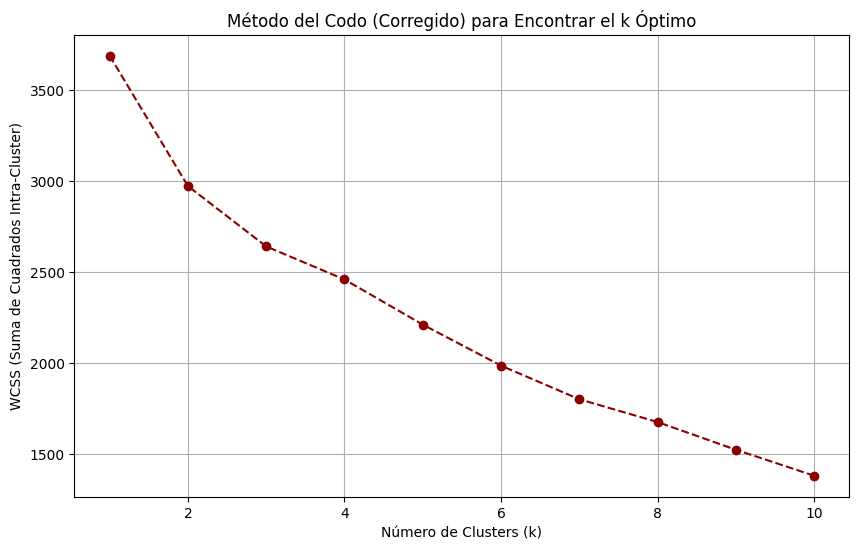

In [59]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- 1. LIMPIAR X_final y Escalar los Datos ---

# !!! ESTA ES LA CORRECCIÓN MÁS IMPORTANTE !!!
# Usamos .dropna() para eliminar las filas con valores NaN
# X_final DEBE ser un DataFrame de pandas para que .dropna() funcione
# Si X_final no es un DataFrame, recréalo a partir de tu df limpio.

try:
    # Asumimos que X_final es un DataFrame.
    X_features_limpio = X_final.dropna()
    print(f"Filas originales en X_final: {len(X_final)}")
    print(f"Filas después de .dropna(): {len(X_features_limpio)}")
    
    if len(X_features_limpio) == 0:
        print("--- ❌ ERROR: ¡.dropna() eliminó todas las filas! Revisa tus datos. ---")
    else:
        scaler = StandardScaler()
        # Escalamos SOLO los datos limpios
        X_scaled = scaler.fit_transform(X_features_limpio) 
        print("--- ✅ Datos limpios y escalados ---")
        
        # 2. Aplicar el Método del Codo (AHORA FUNCIONARÁ)
        wcss = []
        k_range = range(1, 11) 
        
        print("--- Calculando WCSS para k=1 a 10... ---")
        for k in k_range:
            kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
            kmeans.fit(X_scaled) # Esto ya no dará error
            wcss.append(kmeans.inertia_)
        
        print("--- ✅ Cálculo de WCSS completo ---")

        # 3. Visualización del Método del Codo
        plt.figure(figsize=(10, 6))
        plt.plot(k_range, wcss, marker='o', linestyle='--', color='darkred')
        plt.title('Método del Codo (Corregido) para Encontrar el k Óptimo')
        plt.xlabel('Número de Clusters (k)')
        plt.ylabel('WCSS (Suma de Cuadrados Intra-Cluster)')
        plt.grid(True)
        plt.show()

except AttributeError:
    print("--- ❌ ERROR: 'X_final' no es un DataFrame de Pandas ---")
    print("No se pudo usar .dropna(). Asegúrate de que X_final sea el DataFrame con tus columnas numéricas.")
except NameError:
    print("--- ❌ ERROR: 'X_final' no está definido ---")
    print("Por favor, ejecuta la celda donde creas X_final primero.")

In [71]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# --- 1. DEFINIR TUS VARIABLES ---

# !!! Reemplaza esto con tu lista de columnas numéricas !!!
columnas_para_cluster = [
    'lead_time', 
    'adr', 
    'stays_in_week_nights', 
    'previous_cancellations'
    # ... (añade todas tus columnas numéricas)
]

# !!! 'df' debe ser tu DataFrame ORIGINAL (el grande, antes de limpiar nulos)
# !!! Si tu variable original se llama diferente, cámbialo aquí.
# (Si no existe, cárgalo de nuevo, ej: df = pd.read_csv('tu_archivo.csv'))
try:
    df_original = df 
except NameError:
    print("--- ❌ ERROR: Carga tu DataFrame original (ej: 'df') primero ---")
    # (Detiene la ejecución si 'df' no existe)
    raise

# --- 2. RECREAR LA LIMPIEZA DEL EDA ---
# (Este es el paso clave)

# Eliminamos filas que tengan NaN SÓLO en las columnas que nos importan
# Este será nuestro DataFrame final para el análisis
df_final = df_original.dropna(subset=columnas_para_cluster)

# --- 3. PREPARAR DATOS PARA K-MEANS ---

# X_final ahora SÓLO contiene las filas y columnas limpias
X_final = df_final[columnas_para_cluster]

print(f"--- Se usarán {len(df_final)} filas limpias (de {len(df_original)} totales) ---")
print(f"Total de NaNs en X_final ahora: {X_final.isna().sum().sum()} (debería ser 0)")

# --- 4. ESCALAR Y ENTRENAR (Ahora sí) ---

# Escalar SÓLO los datos limpios
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)
print("--- ✅ Datos limpios y escalados ---")

# --- 5. Entrenar el modelo K-Means final ---
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Entrenamos SOLO con los datos escalados y limpios
kmeans_final.fit(X_scaled) 
print("--- ✅ K-Means entrenado ---")

# --- 6. Asignar las etiquetas de clusters ---

# Esto funciona porque len(df_final) es IGUAL a len(kmeans_final.labels_)
df_final['Cluster'] = kmeans_final.labels_

print("\n--- ✅ K-Means Ejecutado y Clusters Asignados (solo a filas limpias) ---")
print("\nDistribución de Registros por Cluster:")
print(df_final['Cluster'].value_counts().sort_index())

--- Se usarán 87395 filas limpias (de 87395 totales) ---
Total de NaNs en X_final ahora: 0 (debería ser 0)
--- ✅ Datos limpios y escalados ---
--- ✅ K-Means entrenado ---

--- ✅ K-Means Ejecutado y Clusters Asignados (solo a filas limpias) ---

Distribución de Registros por Cluster:
Cluster
0    21987
1    21621
2    43748
3       39
Name: count, dtype: int64


In [75]:
import pandas as pd

print("--- 'Receta' de los Ejes (Component Loadings) ---")

try:
    # 1. Asumimos que 'pca' (el modelo) y 'X_final' (tus datos ANTES de escalar) existen.
    # X_final.columns nos da los nombres de las variables originales.
    
    # 2. Crear un DataFrame de "cargas" (loadings)
    # pca.components_ nos dice cuánto "pesa" cada variable en cada componente
    df_loadings = pd.DataFrame(
        pca.components_,
        columns=X_final.columns, # Los nombres de tus variables
        index=['Componente 1 (Eje X)', 'Componente 2 (Eje Y)']
    )

    # 3. Mostrar la tabla (transpuesta para leerla mejor)
    # Ahora las variables son filas y los ejes son columnas
    print(df_loadings.T)


    # 4. Ver qué variables DOMINAN cada eje (¡La parte clave!)
    # Usamos .abs() para ver la magnitud (no importa si es positivo o negativo)
    
    print("\n\n--- 🔍 Variables MÁS Importantes para el Eje X (Componente 1) ---")
    # Ordenamos por la magnitud absoluta
    loadings_eje_x = df_loadings.T['Componente 1 (Eje X)'].abs().sort_values(ascending=False)
    print(loadings_eje_x.head(5))

    print("\n--- 🔍 Variables MÁS Importantes para el Eje Y (Componente 2) ---")
    loadings_eje_y = df_loadings.T['Componente 2 (Eje Y)'].abs().sort_values(ascending=False)
    print(loadings_eje_y.head(5))

except NameError as e:
    print(f"\n--- ❌ ¡ERROR! Parece que una variable no existe ---")
    print(f"Detalle: {e}")
    print("Asegúrate de haber ejecutado la celda del PCA y que 'X_final' (con tus columnas) exista.")
except Exception as e:
    print(f"\n--- ❌ Ocurrió un error inesperado ---")
    print(f"Detalle: {e}")

--- 'Receta' de los Ejes (Component Loadings) ---
                        Componente 1 (Eje X)  Componente 2 (Eje Y)
lead_time                           0.689622              0.166200
adr                                 0.176303             -0.658321
stays_in_week_nights                0.700058              0.061704
previous_cancellations             -0.057066              0.731563


--- 🔍 Variables MÁS Importantes para el Eje X (Componente 1) ---
stays_in_week_nights      0.700058
lead_time                 0.689622
adr                       0.176303
previous_cancellations    0.057066
Name: Componente 1 (Eje X), dtype: float64

--- 🔍 Variables MÁS Importantes para el Eje Y (Componente 2) ---
previous_cancellations    0.731563
adr                       0.658321
lead_time                 0.166200
stays_in_week_nights      0.061704
Name: Componente 2 (Eje Y), dtype: float64


--- Iniciando Mapeo con Pair Plot (sobre una muestra) ---
--- Muestra de 5000 puntos preparada ---
--- 📊 Generando Pair Plot... ---


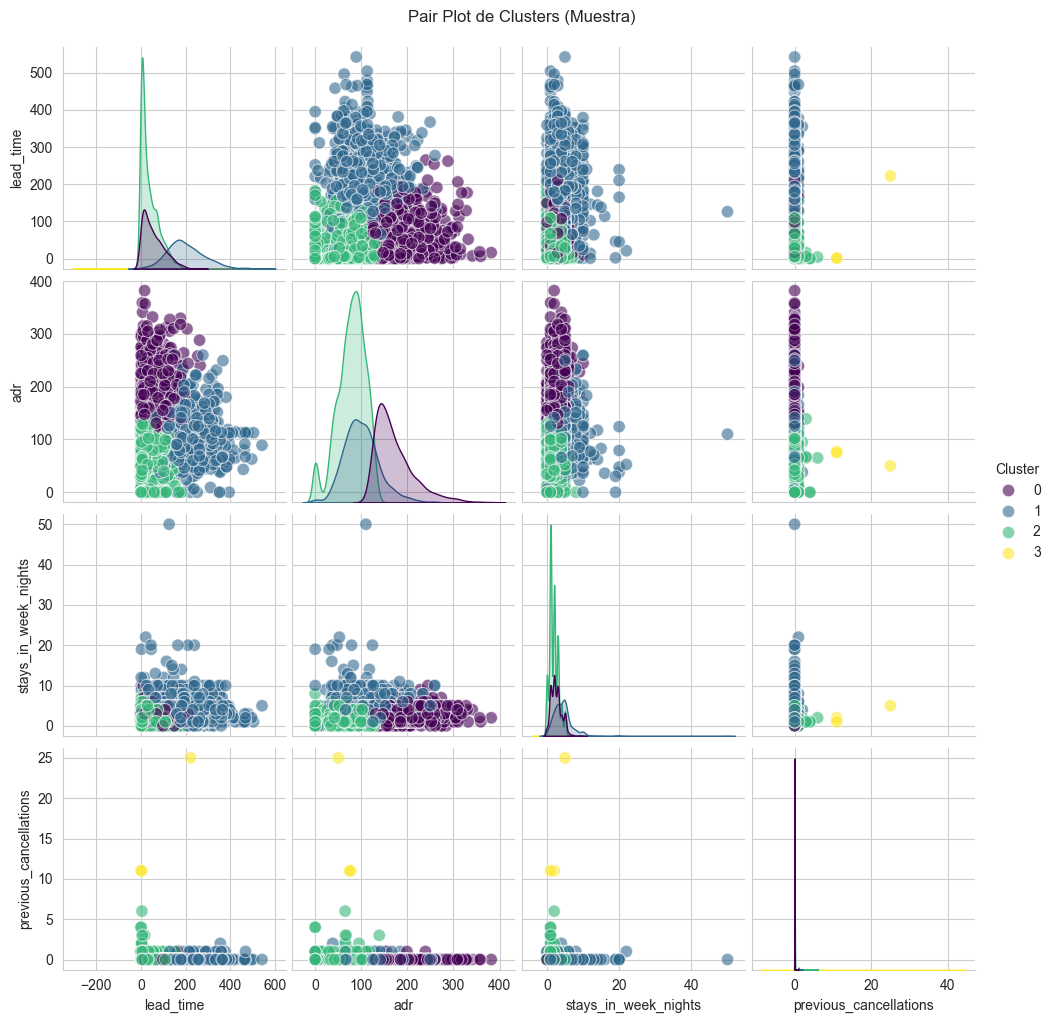

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("--- Iniciando Mapeo con Pair Plot (sobre una muestra) ---")

try:
    # --- 1. Definir las variables a graficar ---
    # ¡Asegúrate de que estas sean tus 4 variables clave!
    # (Las que usaste en X_final)
    columnas_para_plot = [
        'lead_time', 
        'adr', 
        'stays_in_week_nights', 
        'previous_cancellations'
        # ... (añade o quita según tus 4 variables)
    ]
    
    # --- 2. Preparar la Muestra ---
    # Necesitamos las 4 variables Y la columna 'Cluster'
    columnas_totales = columnas_para_plot + ['Cluster']
    
    # Creamos un df solo con esas columnas, desde df_final (¡datos NO escalados!)
    # Usamos .dropna() por si acaso, para que no falle el plot
    df_plot = df_final[columnas_totales].dropna()

    n_muestra = 5000
    if len(df_plot) < n_muestra:
        n_muestra = len(df_plot)
        
    df_sample = df_plot.sample(n_muestra, random_state=42)
    print(f"--- Muestra de {n_muestra} puntos preparada ---")

    # --- 3. Generar el Pair Plot ---
    # ¡Aquí ocurre la magia!
    print("--- 📊 Generando Pair Plot... ---")
    
    # 'hue' colorea por cluster
    # 'kind='scatter'' asegura que sean gráficos de dispersión
    g = sns.pairplot(
        df_sample, 
        hue='Cluster', 
        palette='viridis', 
        diag_kind='kde', # Muestra la densidad en la diagonal
        plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'w'} # Estilo de puntos
    )
    
    g.fig.suptitle("Pair Plot de Clusters (Muestra)", y=1.02)
    plt.show()

except NameError as e:
    print(f"\n--- ❌ ¡ERROR! Parece que 'df_final' no existe ---")
    print(f"Detalle: {e}")
except Exception as e:
    print(f"\n--- ❌ Ocurrió un error inesperado ---")
    print(f"Detalle: {e}")

In [83]:
import pandas as pd

# --- 1. CONFIGURACIÓN MÁGICA PARA EVITAR TRUNCAMIENTO ---
# Le decimos a pandas que muestre hasta 1000 píxeles de ancho
pd.set_option('display.width', 1000)
# Y que muestre todas las columnas (ninguna oculta)
pd.set_option('display.max_columns', None)


# --- 2. CÓDIGO DE PROFILING (EL QUE GENERA LA TABLA) ---
# (Asumimos que 'df_final' existe y tiene la columna 'Cluster')

# Calcula el promedio de TODAS las columnas numéricas para cada cluster
cluster_profile = df_final.groupby('Cluster').mean(numeric_only=True)

print("--- Perfil Promedio de Cada Cluster (Completo) ---")
# Usamos .T (Transponer) para que sea más fácil de leer
print(cluster_profile.T)

--- Perfil Promedio de Cada Cluster (Completo) ---
Cluster                                   0            1            2            3
is_canceled                        0.329285     0.362657     0.204146     0.333333
lead_time                         55.649293   194.046390    35.649561    72.153846
arrival_date_year               2016.336381  2016.291106  2016.107411  2015.769231
arrival_date_week_number          28.685860    28.602701    25.050425    12.692308
arrival_date_day_of_month         16.135444    15.825355    15.652944    12.794872
stays_in_weekend_nights            0.926093     1.566163     0.768264     0.564103
stays_in_week_nights               2.495793     4.333750     1.847010     1.820513
adults                             2.089326     1.949170     1.732216     1.871795
children                           0.331423     0.112483     0.054791     0.000000
babies                             0.013872     0.011193     0.009120     0.000000
is_repeated_guest                  0